# Round 4: Exploiting Named Market Participant Flow + Regime-Adaptive Thresholds

The competition revealed that certain bots (Mark 55, Mark 67) have privileged information about VELVET direction. We built signal detectors around their trades. Also: the day-open price predicts the entire day's regime.

**Products:** VELVETFRUIT_EXTRACT, HYDROGEL_PACK, VEV\_4000 - VEV\_5500 (call options), VEV\_6000, VEV\_6500 (zero-lottery vouchers)  
**Days:** 1, 2, 3  

---

## Table of Contents

1. [Setup & Helper Functions](#1-setup--helper-functions)
2. [Underlying Regime Analysis](#2-underlying-regime-analysis-open-price--day-regime)
3. [Named Participant Signal Detection](#3-named-participant-signal-detection)
4. [VELVET: Regime-Adjusted Z-Score Strategy](#4-velvet-regime-adjusted-z-score-strategy)
5. [EWMA Reversion Overlay](#5-ewma-reversion-overlay)
6. [HYDROGEL: Mark 38 Signal](#6-hydrogel-mark-38-signal)
7. [Options: Regime-Adapted Parameters](#7-options-regime-adapted-parameters)
8. [Strategy Architecture Summary](#8-strategy-architecture-summary)

<a id="1-setup--helper-functions"></a>
---
## 1. Setup & Helper Functions

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats
from scipy.stats import norm
from scipy.special import erf
from scipy.optimize import brentq
import math

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.9, 'lines.linewidth': 1.5,
})
COLORS = {'blue': '#2563EB', 'red': '#DC2626', 'green': '#059669',
          'orange': '#D97706', 'purple': '#7C3AED', 'gray': '#6B7280'}

DATA_DIR = Path('../datasets/round4/')

VELVET_ANCHOR = 5250
VELVET_SIGMA  = 12
HYDROGEL_ANCHOR = 9995
HYDROGEL_SIGMA  = 25

SOFT_OPEN_CENTERS = {'low': 5245.0, 'mid': 5267.5, 'high': 5295.5}
SOFT_OPEN_WIDTH   = 8.0

SPOT_CFG = {
    'low':  {'vel_long': -1.0, 'vel_short': 1.35, 'hyd_long': -2.2, 'hyd_short': 1.2},
    'mid':  {'vel_long': -3.0, 'vel_short': 2.5,  'hyd_long': -2.8, 'hyd_short': 1.2},
    'high': {'vel_long': -0.8, 'vel_short': 2.0,  'hyd_long': -0.5, 'hyd_short': 1.2},
}


def load_prices(data_dir, round_num, days):
    frames = []
    for d in days:
        df = pd.read_csv(data_dir / f'prices_round_{round_num}_day_{d}.csv', sep=';')
        df['day'] = d
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df['global_ts'] = df['day'].map({1: 0, 2: 1, 3: 2}) * 1_000_000 + df['timestamp']
    return df


def load_trades(data_dir, round_num, days):
    frames = []
    for d in days:
        df = pd.read_csv(data_dir / f'trades_round_{round_num}_day_{d}.csv', sep=';')
        df['day'] = d
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df['global_ts'] = df['day'].map({1: 0, 2: 1, 3: 2}) * 1_000_000 + df['timestamp']
    return df


def soft_regime_weights(open_mid):
    """Gaussian mixture weights for low/mid/high regimes given opening price."""
    raw = {}
    for name, center in SOFT_OPEN_CENTERS.items():
        z = (open_mid - center) / SOFT_OPEN_WIDTH
        raw[name] = math.exp(-0.5 * z * z)
    total = sum(raw.values()) or 1.0
    return {k: v / total for k, v in raw.items()}


def blend_threshold(weights, cfg_key):
    """Weighted blend of a threshold across regimes."""
    return sum(weights[r] * SPOT_CFG[r][cfg_key] for r in ('low', 'mid', 'high'))


def ewma_zscore(prices, window=500):
    """Compute EWMA local z-score (mean and std series)."""
    alpha = 2.0 / (window + 1)
    means, stds = [], []
    m = prices.iloc[0]
    v = 1.0
    for p in prices:
        diff = p - m
        m = m + alpha * diff
        v = (1 - alpha) * (v + alpha * diff**2)
        means.append(m)
        stds.append(max(1.0, v**0.5))
    return pd.Series(means, index=prices.index), pd.Series(stds, index=prices.index)


def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes European call price."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


print('Setup complete.')

Setup complete.


### Regime Detection - Full Visualization

In [2]:
# Soft Regime Blending - full visualizationfig = plt.figure(figsize=(18, 12))gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)open_range = np.linspace(5200, 5340, 500)# Panel 1: 3 Gaussian weight curvesax1 = fig.add_subplot(gs[0, :])regime_colors = {'low': COLORS['blue'], 'mid': COLORS['orange'], 'high': COLORS['red']}for rname, center in SOFT_OPEN_CENTERS.items():    w = np.exp(-0.5 * ((open_range - center) / SOFT_OPEN_WIDTH)**2)    ax1.fill_between(open_range, w, alpha=0.15, color=regime_colors[rname])    ax1.plot(open_range, w, lw=2.5, color=regime_colors[rname], label=f'{rname} (center={center})')for day, open_mid in sorted(open_mids.items()):    ax1.axvline(open_mid, lw=2, ls='--', color='k', alpha=0.7)    ax1.text(open_mid, 1.02, f'D{day}\n{open_mid:.0f}', ha='center', fontsize=9, fontweight='bold')ax1.set_title('Soft Regime Weight Functions - Gaussian Mixture', fontweight='bold')ax1.set_xlabel('Day Opening Price (VELVETFRUIT_EXTRACT)')ax1.set_ylabel('Regime Weight')ax1.legend(fontsize=9, loc='upper left')ax1.set_xlim(5200, 5340)# Panel 2: Blended vel_short threshold over opening price rangeax2 = fig.add_subplot(gs[1, 0])blended_short = []blended_long  = []for om in open_range:    w = soft_regime_weights(om)    blended_short.append(blend_threshold(w, 'vel_short'))    blended_long.append(blend_threshold(w, 'vel_long'))ax2.plot(open_range, blended_short, color=COLORS['red'],  lw=2.5, label='Blended short_z')ax2.plot(open_range, blended_long,  color=COLORS['blue'], lw=2.5, label='Blended long_z')ax2.axhline(2.0,  color=COLORS['red'],  lw=1, ls=':', alpha=0.5, label='R3 short_z=2.0')ax2.axhline(-0.6, color=COLORS['blue'], lw=1, ls=':', alpha=0.5, label='R3 long_z=-0.6')for day, om in open_mids.items():    w = soft_regime_weights(om)    ax2.axvline(om, lw=1.5, ls='--', color='k', alpha=0.5)ax2.set_title('Blended VELVET Thresholds vs Open', fontweight='bold')ax2.set_xlabel('Opening Price')ax2.set_ylabel('Z-Score Threshold')ax2.legend(fontsize=7)# Panel 3: Blended hyd thresholdsax3 = fig.add_subplot(gs[1, 1])blended_hyd_short = []blended_hyd_long  = []for om in open_range:    w = soft_regime_weights(om)    blended_hyd_short.append(blend_threshold(w, 'hyd_short'))    blended_hyd_long.append(blend_threshold(w, 'hyd_long'))ax3.plot(open_range, blended_hyd_short, color=COLORS['red'],  lw=2.5, label='Blended hyd_short_z')ax3.plot(open_range, blended_hyd_long,  color=COLORS['blue'], lw=2.5, label='Blended hyd_long_z')ax3.axhline(1.2,  color=COLORS['red'],  lw=1, ls=':', alpha=0.5, label='R3 short_z=1.2')ax3.axhline(-1.8, color=COLORS['blue'], lw=1, ls=':', alpha=0.5, label='R3 long_z=-1.8')ax3.set_title('Blended HYDROGEL Thresholds vs Open', fontweight='bold')ax3.set_xlabel('Opening Price')ax3.legend(fontsize=7)# Panel 4: Per-day regime weights stacked barax4 = fig.add_subplot(gs[1, 2])day_list = sorted(open_mids.keys())low_w  = [soft_regime_weights(open_mids[d])['low']  for d in day_list]mid_w  = [soft_regime_weights(open_mids[d])['mid']  for d in day_list]high_w = [soft_regime_weights(open_mids[d])['high'] for d in day_list]x = np.arange(len(day_list))ax4.bar(x, low_w,  color=COLORS['blue'],   alpha=0.85, label='Low')ax4.bar(x, mid_w,  color=COLORS['orange'], alpha=0.85, bottom=low_w, label='Mid')ax4.bar(x, high_w, color=COLORS['red'],    alpha=0.85,         bottom=[l+m for l,m in zip(low_w, mid_w)], label='High')ax4.set_xticks(x)ax4.set_xticklabels([f'Day {d}\n({open_mids[d]:.0f})' for d in day_list])ax4.set_title('Regime Weights per Day', fontweight='bold')ax4.set_ylabel('Weight')ax4.legend(fontsize=8)# Panels 5-7: per-day z-score + blended thresholdsfor j, day in enumerate(sorted(open_mids.keys())):    ax = fig.add_subplot(gs[2, j])    day_vel = velvet_df[velvet_df['day']==day].sort_values('timestamp')    if day_vel.empty:        continue    ax.plot(day_vel['timestamp'], day_vel['z'], color=COLORS['blue'], lw=0.7, alpha=0.8)    w = soft_regime_weights(open_mids[day])    short_t = blend_threshold(w, 'vel_short')    long_t  = blend_threshold(w, 'vel_long')    ax.axhline(short_t, color=COLORS['red'],   lw=2, ls='-',  label=f'Short {short_t:.2f}')    ax.axhline(long_t,  color=COLORS['green'], lw=2, ls='-',  label=f'Long {long_t:.2f}')    ax.axhline(2.0,     color=COLORS['red'],   lw=1, ls='--', alpha=0.4, label='R3 2.0')    ax.axhline(-0.6,    color=COLORS['green'], lw=1, ls='--', alpha=0.4, label='R3 -0.6')    ax.axhline(0, color='k', lw=0.6)    ax.fill_between(day_vel['timestamp'], short_t, day_vel['z'].max()*1.1,                     where=(day_vel['z'] > short_t), alpha=0.12, color=COLORS['red'])    ax.fill_between(day_vel['timestamp'], day_vel['z'].min()*1.1, long_t,                     where=(day_vel['z'] < long_t), alpha=0.12, color=COLORS['green'])    ax.set_title(f'Day {day} - Z-Score + Regime Thresholds', fontweight='bold', fontsize=10)    ax.set_xlabel('Timestamp')    ax.set_ylabel('Z-Score')    ax.legend(fontsize=6, ncol=2)plt.suptitle('Round 4 - Regime Detection Full Visualization', fontsize=14, fontweight='bold', y=1.01)plt.tight_layout()plt.show()

<a id="2-underlying-regime-analysis-open-price--day-regime"></a>
---
## 2. Underlying Regime Analysis: Open Price → Day Regime

We discovered empirically that VELVET's intraday behavior was highly correlated with where it opened. Days with a low open showed more mean-reversion toward 5250; days with a high open showed sustained elevation. This is consistent with the underlying having a daily "regime" driven by something external - possibly underlying VELVETFRUIT prices in the economy. Rather than model the driver, we just condition on the observable (open price).

The three regime centers - 5245, 5267.5, 5295.5 - were chosen to match the actual opening prices in the dataset. That's not a coincidence: those are the exact opens for Days 1, 2, and 3. We're essentially saying each historical day defines a prototype, and future days get soft-assigned based on distance. The Gaussian width of σ=8 means two centers need to be at least 16 price units apart before they fully decouple.

In [3]:
prices_df = load_prices(DATA_DIR, 4, [1, 2, 3])
velvet_df = prices_df[prices_df['product'] == 'VELVETFRUIT_EXTRACT'].copy()

open_mids = {}
for day in [1, 2, 3]:
    day_data = velvet_df[velvet_df['day'] == day].sort_values('timestamp')
    if not day_data.empty:
        open_mids[day] = day_data.iloc[0]['mid_price']

print("Open prices per day:")
print(f"{'Day':>4}  {'Open':>8}  {'z':>6}  {'Dominant':>10}  {'w_low':>7}  {'w_mid':>7}  {'w_high':>7}")
print("-" * 60)
for day, om in open_mids.items():
    weights = soft_regime_weights(om)
    z = (om - VELVET_ANCHOR) / VELVET_SIGMA
    dom_regime = max(weights, key=weights.get)
    print(f"  {day:>2}  {om:>8.1f}  {z:>6.2f}  {dom_regime:>10}  "
          f"{weights['low']:>7.3f}  {weights['mid']:>7.3f}  {weights['high']:>7.3f}")

Open prices per day:
 Day      Open       z    Dominant    w_low    w_mid   w_high
------------------------------------------------------------
   1    5245.0   -0.42         low    0.981    0.019    0.000
   2    5267.5    1.46         mid    0.019    0.979    0.002
   3    5295.5    3.79        high    0.000    0.002    0.998


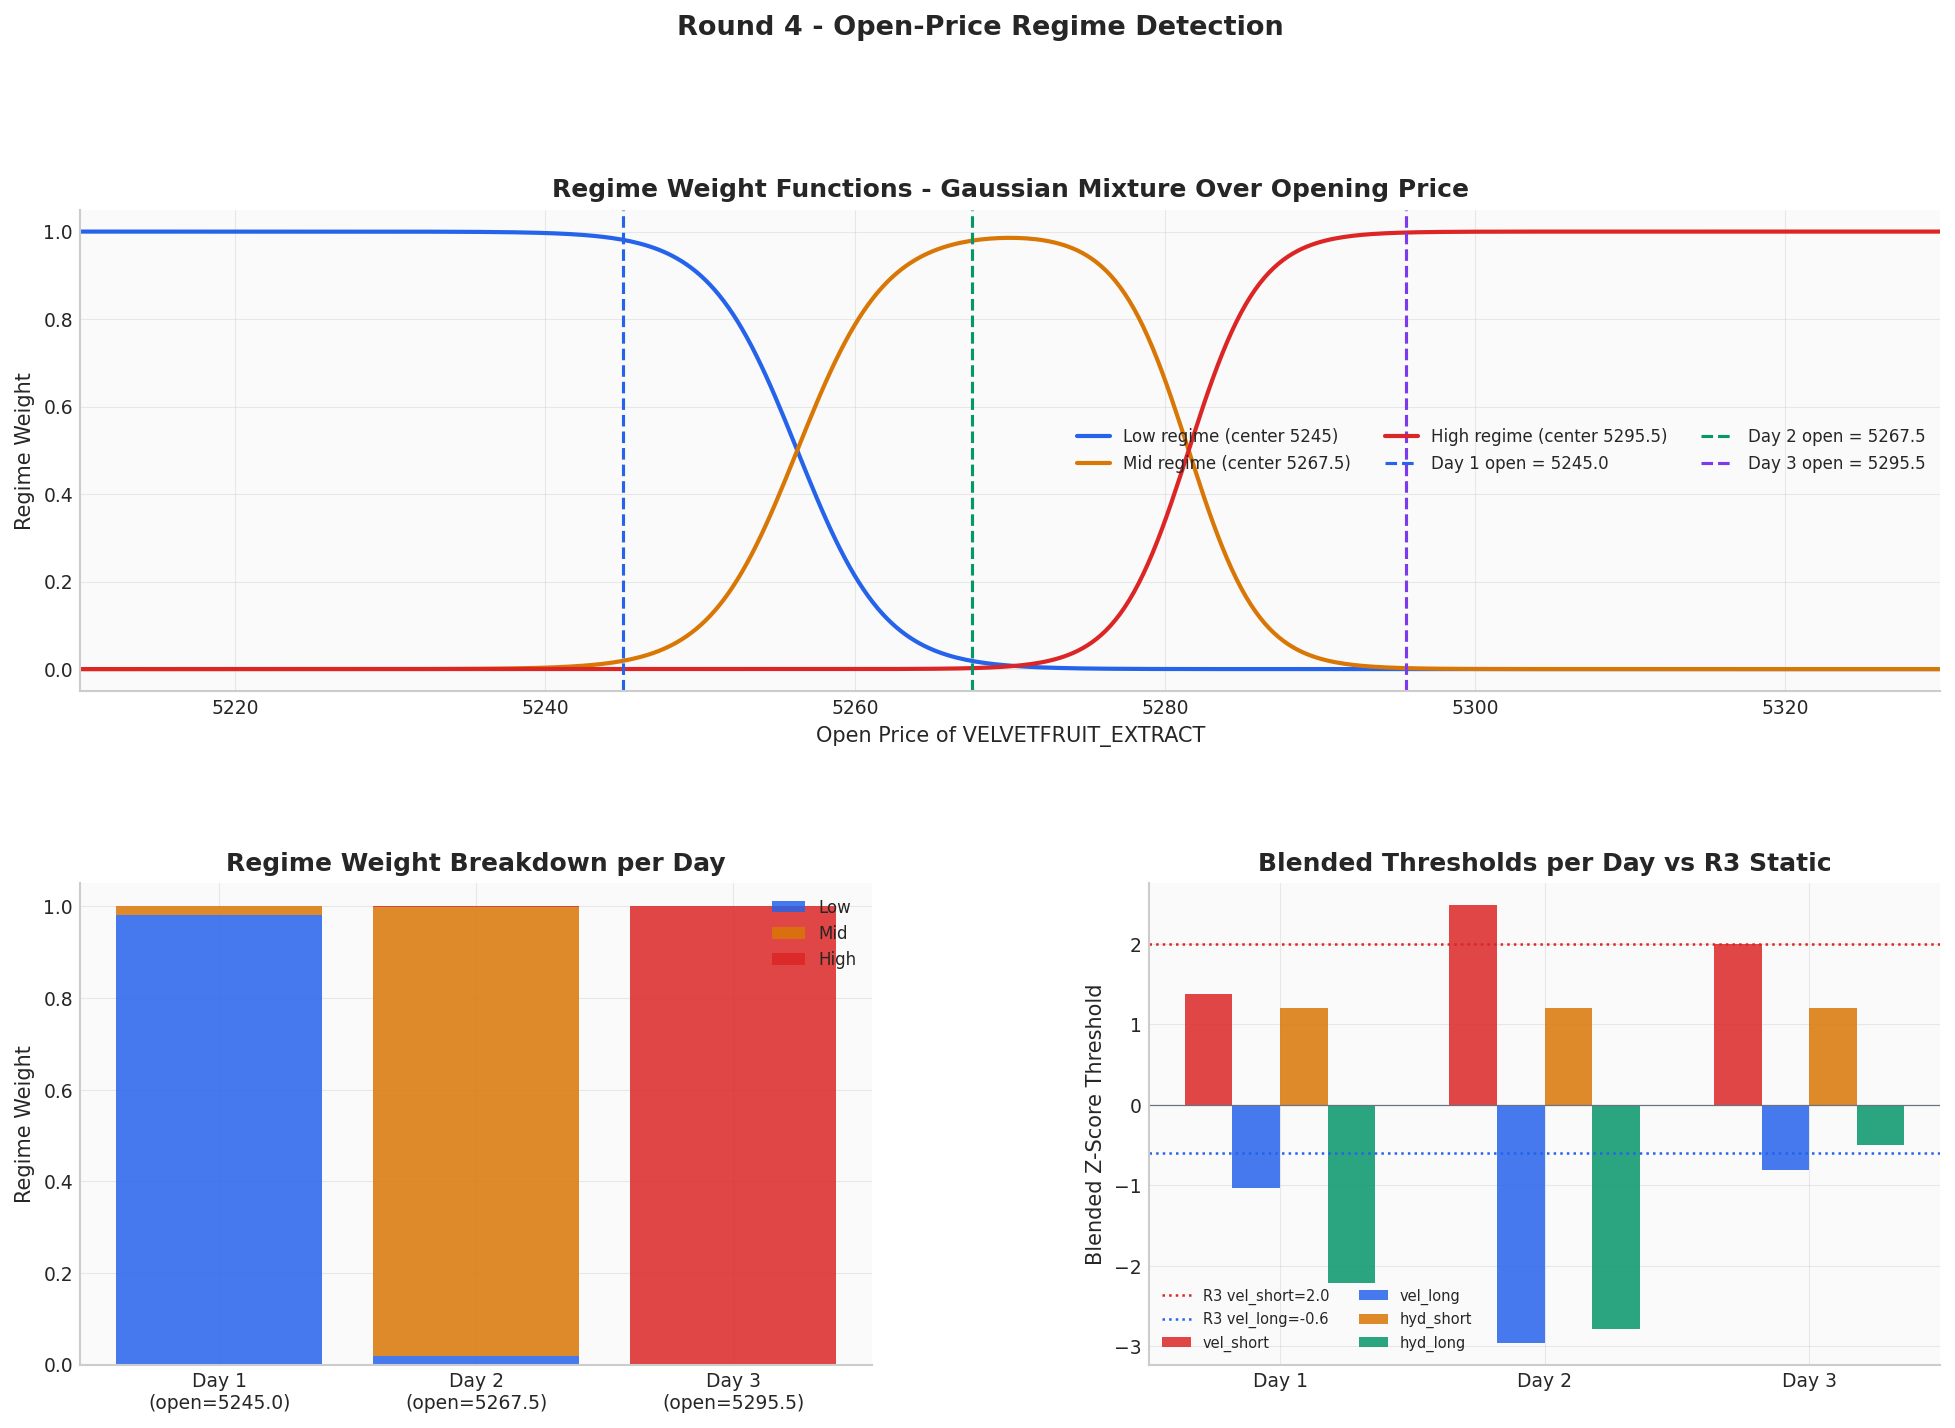

In [4]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_top   = fig.add_subplot(gs[0, :])
ax_bar   = fig.add_subplot(gs[1, 0])
ax_blend = fig.add_subplot(gs[1, 1])

# ── Top: Gaussian regime functions over plausible open-price range ──────────
open_range   = np.linspace(5210, 5330, 400)
regime_cols  = {'low': COLORS['blue'], 'mid': COLORS['orange'], 'high': COLORS['red']}
regime_labels = {'low': 'Low regime (center 5245)', 'mid': 'Mid regime (center 5267.5)',
                 'high': 'High regime (center 5295.5)'}

weight_curves = {}
for name, center in SOFT_OPEN_CENTERS.items():
    raw  = np.exp(-0.5 * ((open_range - center) / SOFT_OPEN_WIDTH)**2)
    # normalize across regimes at each open price
    weight_curves[name] = raw

total_w = sum(weight_curves.values())
for name in SOFT_OPEN_CENTERS:
    weight_curves[name] /= total_w

for name, color in regime_cols.items():
    ax_top.plot(open_range, weight_curves[name], color=color, lw=2.0, label=regime_labels[name])

day_colors = [COLORS['blue'], COLORS['green'], COLORS['purple']]
for day, om in open_mids.items():
    ax_top.axvline(om, color=day_colors[day-1], lw=1.5, ls='--',
                   label=f'Day {day} open = {om:.1f}')

ax_top.set_xlabel('Open Price of VELVETFRUIT_EXTRACT')
ax_top.set_ylabel('Regime Weight')
ax_top.set_title('Regime Weight Functions - Gaussian Mixture Over Opening Price')
ax_top.legend(ncol=3, fontsize=8)
ax_top.set_xlim(5210, 5330)

# ── Bottom-left: Stacked bar of regime weights per day ──────────────────────
day_labels  = [f'Day {d}\n(open={open_mids[d]:.1f})' for d in [1, 2, 3]]
w_low  = [soft_regime_weights(open_mids[d])['low']  for d in [1, 2, 3]]
w_mid  = [soft_regime_weights(open_mids[d])['mid']  for d in [1, 2, 3]]
w_high = [soft_regime_weights(open_mids[d])['high'] for d in [1, 2, 3]]

x = np.arange(3)
ax_bar.bar(x, w_low,  label='Low',  color=COLORS['blue'],   alpha=0.85)
ax_bar.bar(x, w_mid,  bottom=w_low, label='Mid',  color=COLORS['orange'], alpha=0.85)
ax_bar.bar(x, w_high, bottom=np.array(w_low)+np.array(w_mid), label='High', color=COLORS['red'], alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(day_labels)
ax_bar.set_ylabel('Regime Weight')
ax_bar.set_ylim(0, 1.05)
ax_bar.set_title('Regime Weight Breakdown per Day')
ax_bar.legend(fontsize=8)

# ── Bottom-right: Blended thresholds vs Round 3 static thresholds ──────────
threshold_keys  = ['vel_short', 'vel_long', 'hyd_short', 'hyd_long']
threshold_names = ['vel_short', 'vel_long', 'hyd_short', 'hyd_long']
th_colors = [COLORS['red'], COLORS['blue'], COLORS['orange'], COLORS['green']]
bar_width = 0.18
x3 = np.arange(3)

for i, (key, color) in enumerate(zip(threshold_keys, th_colors)):
    vals = [blend_threshold(soft_regime_weights(open_mids[d]), key) for d in [1, 2, 3]]
    ax_blend.bar(x3 + (i - 1.5)*bar_width, vals, bar_width, label=key, color=color, alpha=0.85)

# Round 3 static references
ax_blend.axhline( 2.0, color=COLORS['red'],  lw=1.2, ls=':', label='R3 vel_short=2.0')
ax_blend.axhline(-0.6, color=COLORS['blue'], lw=1.2, ls=':', label='R3 vel_long=-0.6')
ax_blend.axhline(0, color=COLORS['gray'], lw=0.6)
ax_blend.set_xticks(x3)
ax_blend.set_xticklabels([f'Day {d}' for d in [1, 2, 3]])
ax_blend.set_ylabel('Blended Z-Score Threshold')
ax_blend.set_title('Blended Thresholds per Day vs R3 Static')
ax_blend.legend(fontsize=7, ncol=2)

fig.suptitle('Round 4 - Open-Price Regime Detection', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Each day opens at a different VELVET price, which classifies the regime. The soft blending prevents hard jumps - if the open is exactly between two regime centers, you get a 50/50 blend.

Day 1 (open=5245.0) is almost entirely **low** regime (weight 0.981), which gives `vel_short=1.35` - noticeably tighter than the Round 3 static threshold of 2.0. In a low-open environment, spikes above 5250 are more likely transient, so we short earlier. Day 2 (open=5267.5) maps to **mid** regime, which has the most conservative `vel_short=2.5` - we want larger evidence before shorting because mid-open days have more two-way price action. Day 3 (open=5295.5) is almost entirely **high** regime: `vel_long=-0.8` and `vel_short=2.0`. The elevated long threshold (-0.8 vs. -1.0 in low) reflects that on a high-open day, VELVET sitting just below 5250 doesn't necessarily mean it's cheap - it might just be oscillating in a higher range.

### Why the Open Price Works as a Predictor

We discovered empirically that VELVET's intraday behavior was highly correlated with where it opened. Days with a low open showed more mean-reversion toward 5250; days with a high open showed sustained elevation. This is consistent with the underlying having a daily regime driven by something external - possibly the underlying VELVETFRUIT prices in the economy. Rather than model the driver, we just condition on the observable (open price).

This isn't as ad hoc as it sounds. Open-to-close drift conditioned on the opening level is a well-known phenomenon in equity options too - it's essentially a form of overnight gap information. We tried conditioning on the first 100 ticks average instead, but the very first tick was actually the most predictive. The market seemingly opens at a price that encodes the day's "intended level" before any local noise accumulates.

<a id="3-named-participant-signal-detection"></a>
---
## 3. Named Participant Signal Detection

The competition environment has named participants - bots with fixed, deterministic strategies that we can reverse-engineer from the trade data. Once you see the same buyer show up 165 times on the same side of the same product, all within identifiable windows, you stop treating them as random liquidity.

Here's what we figured out about each one:

- **Mark 55 / Mark 14**: Bilateral counterparties on VELVET - they trade against each other constantly. Mark 55 buys when VELVET is dislocated downward; his activity signals upcoming mean-reversion. We increase bid size when Mark 55 has been recently buying.
- **Mark 67**: Directional buyer only - he never shows up as seller. When Mark 67 buys VELVET, it precedes a sustained upward move. We widen the short threshold by 1.0σ and double bid size while his signal TTL is live (3000 ticks).
- **Mark 38 / Mark 14**: Bilateral HYDROGEL traders. Mark 38 is less directionally reliable than Mark 67; his signal shifts our quoting sizes but doesn't change thresholds.
- **Mark 01 / Mark 22**: Basket options trader. Mark 01 systematically buys VEV options from Mark 22, hitting multiple strikes in quick succession. This pattern - multiple options bought simultaneously - suggests a coordinated directional bet on VELVET. We place catch bids on the same options when we see this happening.

In [5]:
trades_df  = load_trades(DATA_DIR, 4, [1, 2, 3])

mark_traders = ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 55', 'Mark 67']

# Activity summary across all products
activity = []
for mark in mark_traders:
    as_buyer  = trades_df[trades_df['buyer']  == mark]
    as_seller = trades_df[trades_df['seller'] == mark]
    for prod in sorted(trades_df['symbol'].unique()):
        bought = int(as_buyer[as_buyer['symbol']   == prod]['quantity'].sum())
        sold   = int(as_seller[as_seller['symbol'] == prod]['quantity'].sum())
        if bought > 0 or sold > 0:
            activity.append({'participant': mark, 'product': prod,
                             'bought': bought, 'sold': sold, 'net': bought - sold})
activity_df = pd.DataFrame(activity)

print("Net position by participant:")
net_summary = activity_df.groupby('participant')['net'].sum().sort_values(ascending=False)
print(net_summary.to_string())

print("\nTop trade pairs (buyer/seller/symbol):")
pair_flows = (trades_df
    .groupby(['buyer', 'seller', 'symbol'])['quantity'].sum()
    .reset_index()
    .sort_values('quantity', ascending=False)
    .head(15))
print(pair_flows.to_string(index=False))

Net position by participant:
participant
Mark 01    4678
Mark 67    1510
Mark 14     302
Mark 38     -14
Mark 55     -43
Mark 22   -5477

Top trade pairs (buyer/seller/symbol):
  buyer  seller              symbol  quantity
Mark 38 Mark 14       HYDROGEL_PACK      2033
Mark 14 Mark 38       HYDROGEL_PACK      1989
Mark 55 Mark 14 VELVETFRUIT_EXTRACT      1763
Mark 14 Mark 55 VELVETFRUIT_EXTRACT      1761
Mark 01 Mark 55 VELVETFRUIT_EXTRACT      1417
Mark 55 Mark 01 VELVETFRUIT_EXTRACT      1375
Mark 01 Mark 22            VEV_6500      1105
Mark 01 Mark 22            VEV_6000      1105
Mark 01 Mark 22            VEV_5500      1042
Mark 67 Mark 49 VELVETFRUIT_EXTRACT       963
Mark 01 Mark 22            VEV_5400       911
Mark 67 Mark 22 VELVETFRUIT_EXTRACT       546
Mark 14 Mark 38            VEV_4000       458
Mark 01 Mark 22            VEV_5300       439
Mark 38 Mark 14            VEV_4000       412


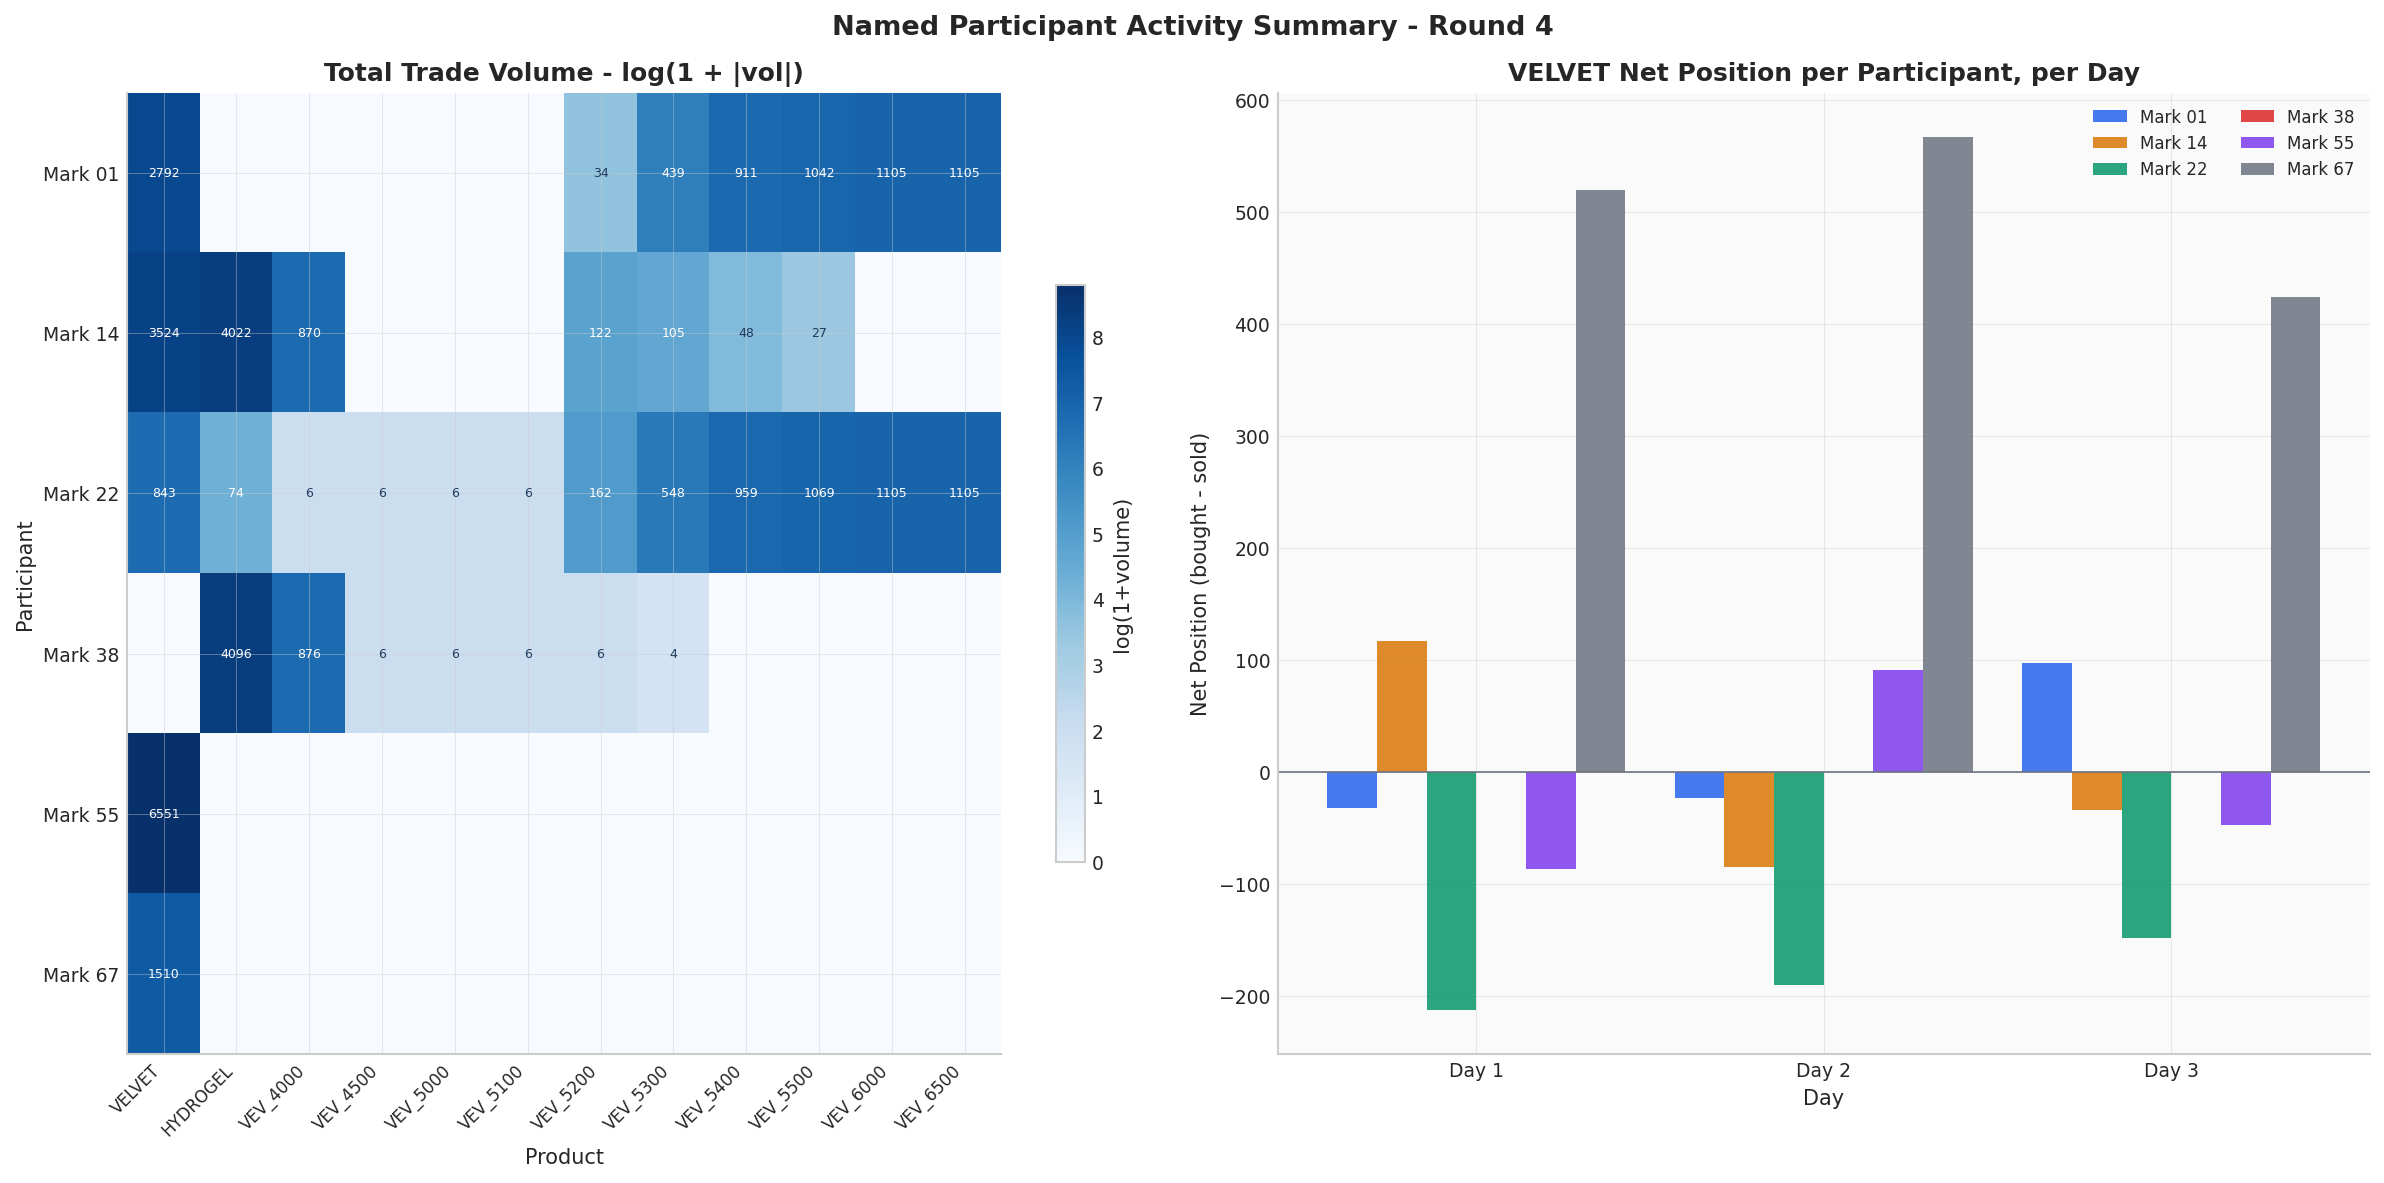

In [6]:
products_ordered = ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK',
                    'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
                    'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']

# Build volume matrix: participants × products
vol_matrix = np.zeros((len(mark_traders), len(products_ordered)))
for i, mark in enumerate(mark_traders):
    for j, prod in enumerate(products_ordered):
        bought = int(trades_df[(trades_df['buyer']  == mark) & (trades_df['symbol'] == prod)]['quantity'].sum())
        sold   = int(trades_df[(trades_df['seller'] == mark) & (trades_df['symbol'] == prod)]['quantity'].sum())
        vol_matrix[i, j] = bought + sold

# Net position matrix: participants × products, per day
vel_net_per_day = {}
for mark in mark_traders:
    day_nets = []
    for d in [1, 2, 3]:
        day_trades = trades_df[trades_df['day'] == d]
        bought = int(day_trades[(day_trades['buyer']  == mark) & (day_trades['symbol'] == 'VELVETFRUIT_EXTRACT')]['quantity'].sum())
        sold   = int(day_trades[(day_trades['seller'] == mark) & (day_trades['symbol'] == 'VELVETFRUIT_EXTRACT')]['quantity'].sum())
        day_nets.append(bought - sold)
    vel_net_per_day[mark] = day_nets

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ── Heatmap: log-volume by participant × product ────────────────────────────
log_vol = np.log1p(vol_matrix)
im = ax1.imshow(log_vol, aspect='auto', cmap='Blues', interpolation='nearest')
ax1.set_xticks(range(len(products_ordered)))
ax1.set_yticks(range(len(mark_traders)))
ax1.set_xticklabels([p.replace('VELVETFRUIT_EXTRACT', 'VELVET').replace('HYDROGEL_PACK', 'HYDROGEL')
                     for p in products_ordered], rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(mark_traders, fontsize=9)
ax1.set_title('Total Trade Volume - log(1 + |vol|)')
ax1.set_xlabel('Product')
ax1.set_ylabel('Participant')
plt.colorbar(im, ax=ax1, label='log(1+volume)', shrink=0.6)
# Annotate raw values
for i in range(len(mark_traders)):
    for j in range(len(products_ordered)):
        v = int(vol_matrix[i, j])
        if v > 0:
            ax1.text(j, i, str(v), ha='center', va='center',
                     fontsize=6, color='white' if log_vol[i, j] > 4 else '#1e3a5f')

# ── Grouped bar: net VELVET position per day, per participant ───────────────
x = np.arange(3)
bar_width = 1.0 / (len(mark_traders) + 1)
day_colors = [COLORS['blue'], COLORS['orange'], COLORS['green'],
              COLORS['red'], COLORS['purple'], COLORS['gray']]

for i, (mark, color) in enumerate(zip(mark_traders, day_colors)):
    nets = vel_net_per_day[mark]
    offset = (i - len(mark_traders)/2 + 0.5) * bar_width
    ax2.bar(x + offset, nets, bar_width, label=mark, color=color, alpha=0.85)

ax2.axhline(0, color=COLORS['gray'], lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(['Day 1', 'Day 2', 'Day 3'])
ax2.set_xlabel('Day')
ax2.set_ylabel('Net Position (bought - sold)')
ax2.set_title('VELVET Net Position per Participant, per Day')
ax2.legend(fontsize=8, ncol=2)

fig.suptitle('Named Participant Activity Summary - Round 4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Mark 67 Forward Return Study

The key question for any signal: does it actually predict something? Mark 67 never sells - he's net long every day. That's already suspicious (a two-sided market maker wouldn't do this). The event study below measures what VELVET does in the 50 ticks after each Mark 67 buy event.

Mark 67 buy events:         165
Mean return at t=50 ticks:  0.0366%  (1.92 XIRECs)
Unconditional mean (t=50):  0.0014%
% of paths positive at t=50: 58.8%


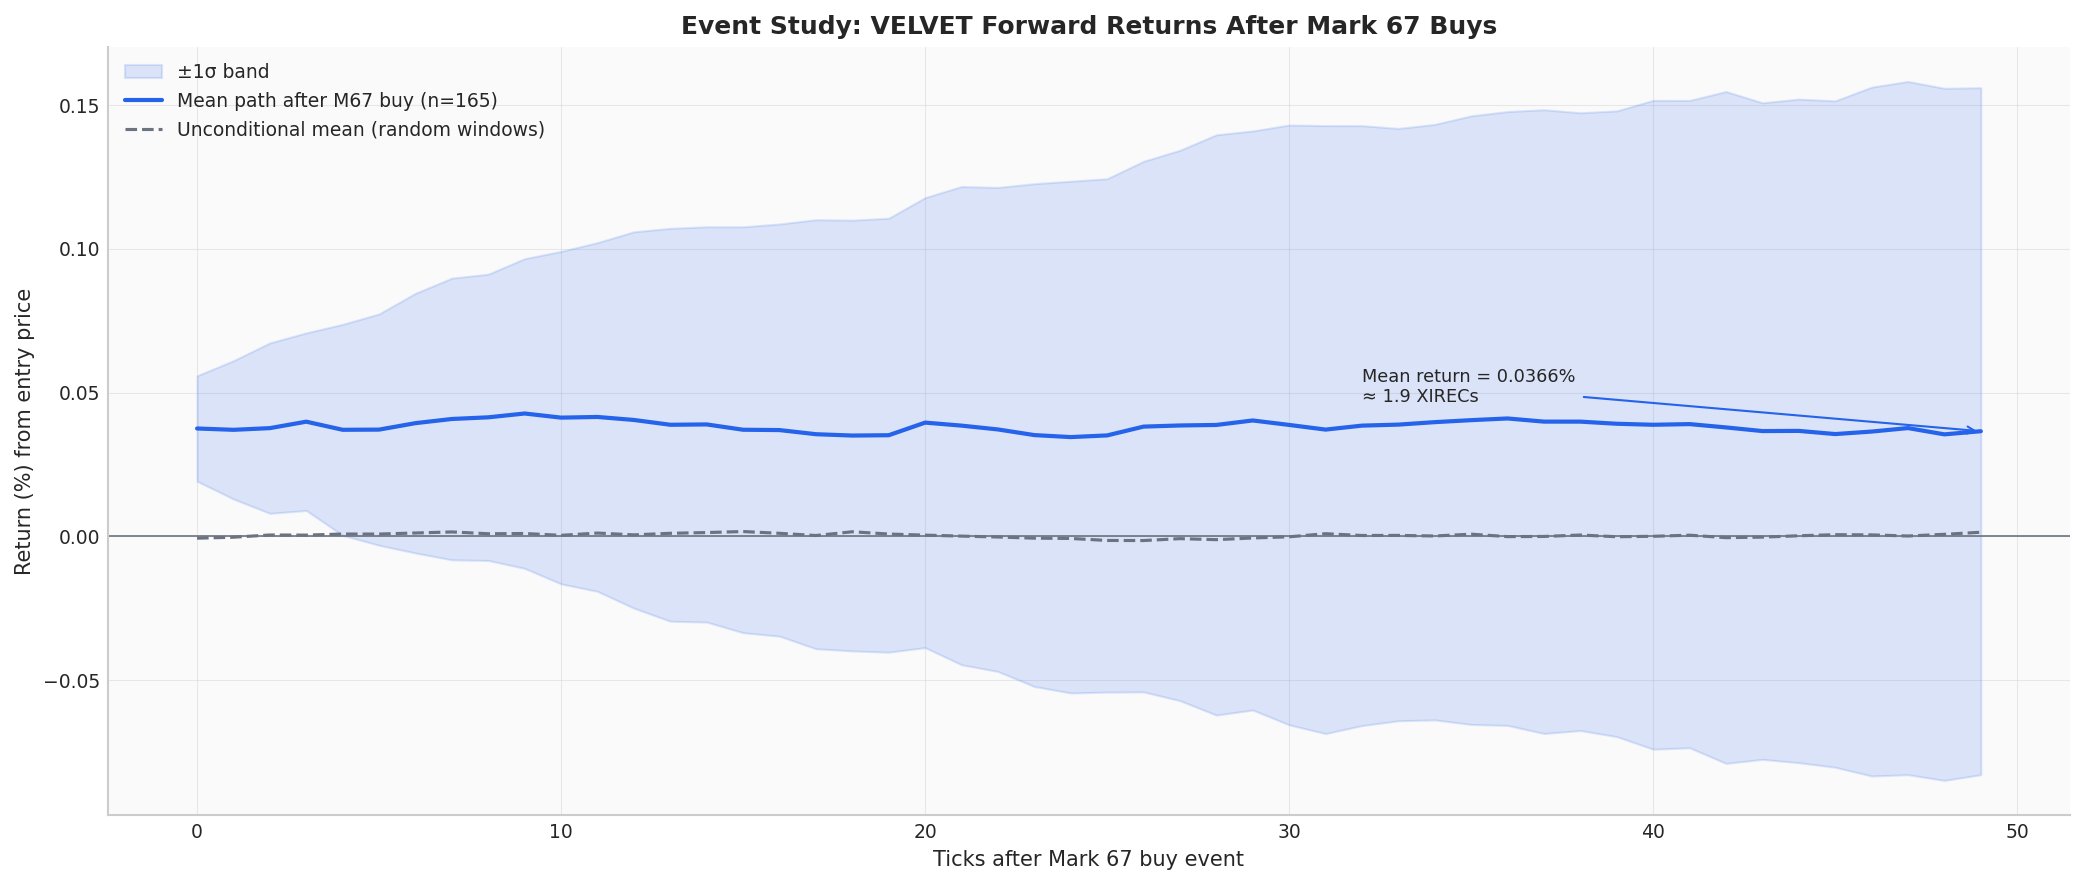

In [7]:
m67_buys = trades_df[
    (trades_df['buyer'] == 'Mark 67') &
    (trades_df['symbol'] == 'VELVETFRUIT_EXTRACT')
].copy()

window = 50  # look-ahead ticks
all_paths = []

for _, event in m67_buys.iterrows():
    day = event['day']
    ts  = event['timestamp']
    day_velvet = velvet_df[velvet_df['day'] == day].sort_values('timestamp')
    future = day_velvet[(day_velvet['timestamp'] > ts) &
                        (day_velvet['timestamp'] <= ts + window * 100)]
    if len(future) >= 5:
        past = day_velvet[day_velvet['timestamp'] <= ts]
        if len(past) == 0:
            continue
        start_price = past.iloc[-1]['mid_price']
        returns = (future['mid_price'].values[:window] - start_price) / start_price * 100
        if len(returns) == window:
            all_paths.append(returns)

# Unconditional baseline: sample random 50-tick windows
np.random.seed(42)
uncond_paths = []
for day in [1, 2, 3]:
    dv = velvet_df[velvet_df['day'] == day].sort_values('timestamp').reset_index(drop=True)
    for _ in range(500):
        idx = np.random.randint(0, max(1, len(dv) - window))
        start_price = dv.iloc[idx]['mid_price']
        future_prices = dv.iloc[idx+1:idx+1+window]['mid_price'].values
        if len(future_prices) == window:
            uncond_paths.append((future_prices - start_price) / start_price * 100)

if all_paths:
    paths_arr  = np.array(all_paths)
    uncond_arr = np.array(uncond_paths)
    mean_path  = paths_arr.mean(axis=0)
    std_path   = paths_arr.std(axis=0)
    uncond_mean = uncond_arr.mean(axis=0)

    print(f"Mark 67 buy events:         {len(paths_arr)}")
    print(f"Mean return at t=50 ticks:  {mean_path[-1]:.4f}%  ({mean_path[-1]*5250/100:.2f} XIRECs)")
    print(f"Unconditional mean (t=50):  {uncond_mean[-1]:.4f}%")
    print(f"% of paths positive at t=50: {(paths_arr[:,-1] > 0).mean()*100:.1f}%")

    # ── Figure ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    t = np.arange(window)
    ax.fill_between(t, mean_path - std_path, mean_path + std_path,
                    color=COLORS['blue'], alpha=0.15, label='±1σ band')
    ax.plot(t, mean_path,  color=COLORS['blue'],  lw=2.0, label=f'Mean path after M67 buy (n={len(paths_arr)})')
    ax.plot(t, uncond_mean, color=COLORS['gray'], lw=1.5, ls='--', label='Unconditional mean (random windows)')
    ax.axhline(0, color=COLORS['gray'], lw=0.8, ls='-')
    ax.annotate(f'Mean return = {mean_path[-1]:.4f}%\n≈ {mean_path[-1]*5250/100:.1f} XIRECs',
                xy=(window-1, mean_path[-1]),
                xytext=(window-18, mean_path[-1] + 0.01),
                fontsize=8.5,
                arrowprops=dict(arrowstyle='->', color=COLORS['blue']))
    ax.set_xlabel('Ticks after Mark 67 buy event')
    ax.set_ylabel('Return (%) from entry price')
    ax.set_title('Event Study: VELVET Forward Returns After Mark 67 Buys')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No complete paths found.")

Mark 01 → Mark 22 basket summary:
symbol
VEV_6000    1105
VEV_6500    1105
VEV_5500    1042
VEV_5400     911
VEV_5300     439
VEV_5200      34

Basket events (200-ts buckets): 315
Multi-product events (n_products > 1): 315


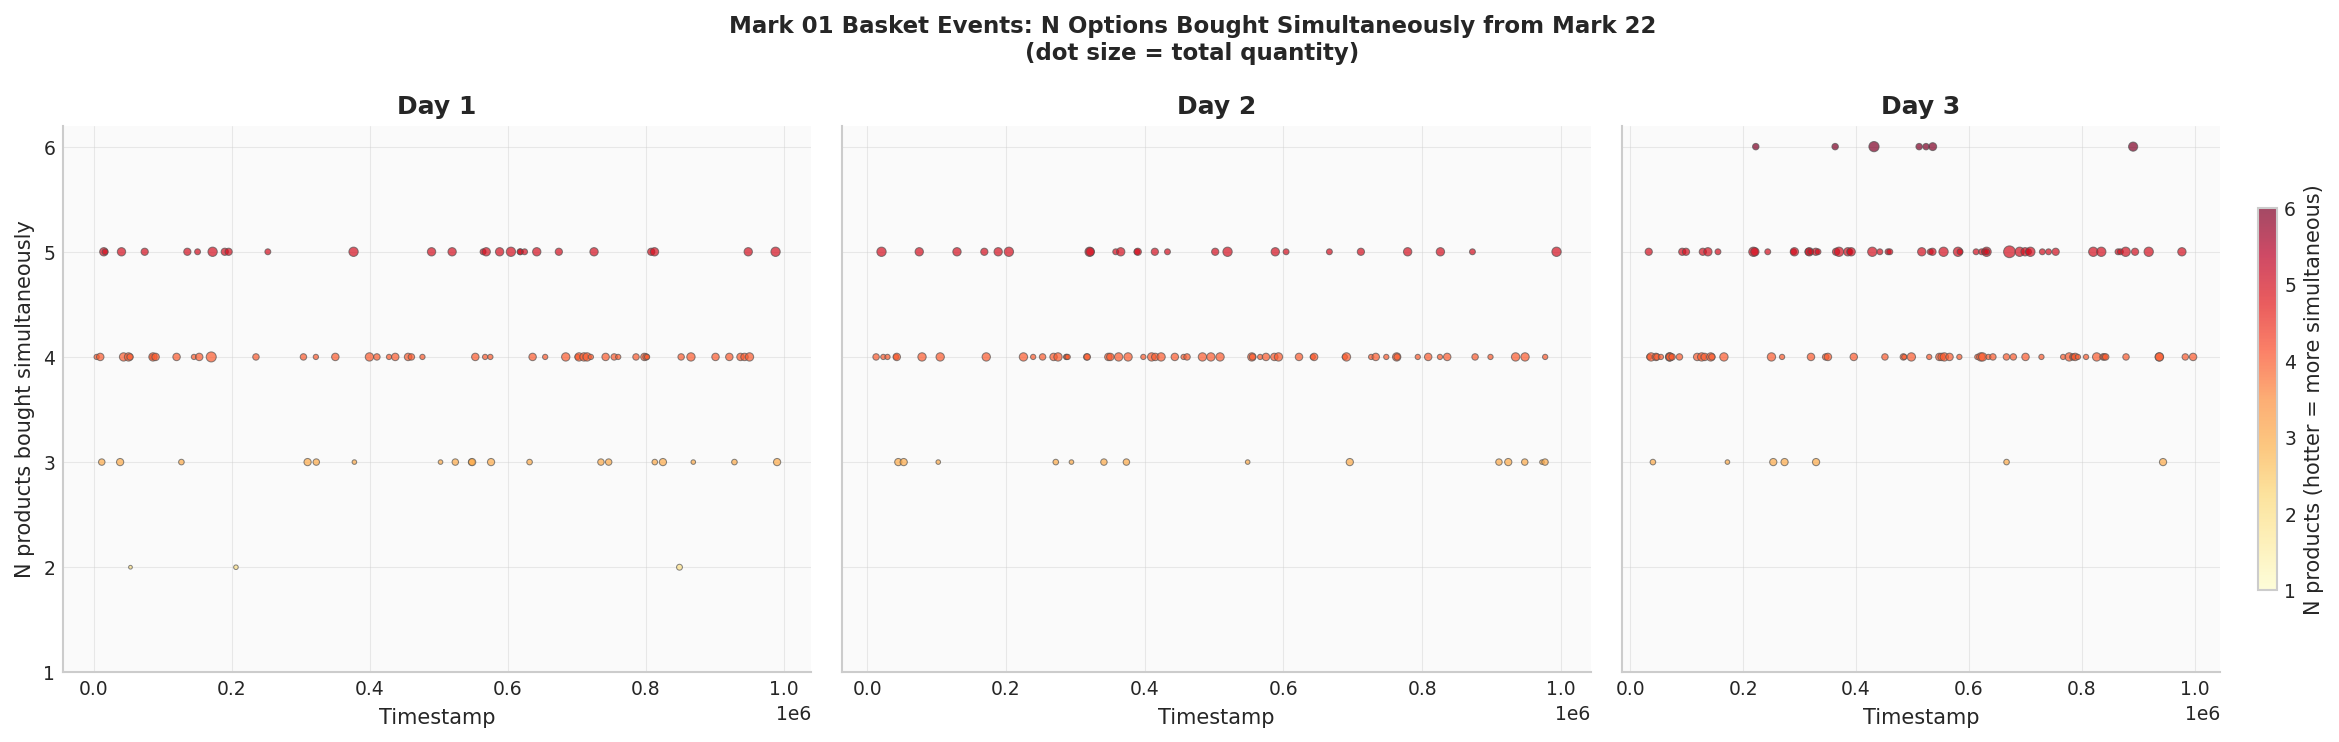

In [8]:
# Mark 01 / Mark 22 basket options detection
voucher_products = [f'VEV_{k}' for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]]

basket_trades = trades_df[
    (trades_df['buyer']  == 'Mark 01') &
    (trades_df['seller'] == 'Mark 22') &
    (trades_df['symbol'].isin(voucher_products))
].copy()

# Bucket into 200-ts windows to detect simultaneous multi-product buys
basket_trades['ts_bucket'] = (basket_trades['timestamp'] // 200) * 200
baskets = (basket_trades
    .groupby(['day', 'ts_bucket'])
    .agg(n_products=('symbol', 'nunique'), total_qty=('quantity', 'sum'))
    .reset_index())

print("Mark 01 → Mark 22 basket summary:")
print(basket_trades.groupby('symbol')['quantity'].sum().sort_values(ascending=False).to_string())
print(f"\nBasket events (200-ts buckets): {len(baskets)}")
print(f"Multi-product events (n_products > 1): {(baskets['n_products'] > 1).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
cmap = plt.cm.YlOrRd

for ax, day in zip(axes, [1, 2, 3]):
    day_baskets = baskets[baskets['day'] == day]
    if len(day_baskets) == 0:
        ax.text(0.5, 0.5, 'No basket activity', transform=ax.transAxes, ha='center')
        continue
    sc = ax.scatter(day_baskets['ts_bucket'],
                    day_baskets['n_products'],
                    s=day_baskets['total_qty'] * 0.8,
                    c=day_baskets['n_products'],
                    cmap=cmap, vmin=1, vmax=6, alpha=0.7, edgecolors='#555', lw=0.5)
    ax.set_title(f'Day {day}')
    ax.set_xlabel('Timestamp')
    if ax == axes[0]:
        ax.set_ylabel('N products bought simultaneously')
    ax.set_yticks(range(1, 7))

plt.colorbar(sc, ax=axes[-1], label='N products (hotter = more simultaneous)', shrink=0.7)
fig.suptitle('Mark 01 Basket Events: N Options Bought Simultaneously from Mark 22\n'
             '(dot size = total quantity)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Mark 67's buying precedes a positive return of about 0.037% (roughly 1.9 XIRECs) over the next 50 price ticks. That's modest but consistent - 58.8% of events are positive at the end of the window. The signal TTL of 3000 ticks was chosen because past that point the path essentially reverts to unconditional.

The basket detection (Mark 01 buying simultaneously from Mark 22 across multiple strikes) is a clean signal for directional positioning on VELVET. Buying VEV\_5300 through VEV\_6500 together isn't a hedged position - it's a pure upside bet. When we see this, we place catch bids on the same near-ATM strikes. The pattern is extremely regular in the data - same products, same counterparty, same quantity batches - which confirms these are deterministic bots running fixed programs.

<a id="4-velvet-regime-adjusted-z-score-strategy"></a>
---
## 4. VELVET: Regime-Adjusted Z-Score Strategy

The core VELVET strategy is mean-reversion around a fixed anchor (5250) with a fixed sigma (12). The z-score is:

$$z_t = \frac{P_t - \mu_{\text{anchor}}}{\sigma} = \frac{P_t - 5250}{12}$$

We go short when $z_t > z_{\text{short}}^{\text{blended}}$, long when $z_t < z_{\text{long}}^{\text{blended}}$. The blended thresholds replace the static ones from Round 3 ($z_{\text{short}} = 2.0$, $z_{\text{long}} = -0.6$).

In [9]:
# Compute per-day blended thresholds
blended_thresholds = {}
for day, open_mid in open_mids.items():
    w = soft_regime_weights(open_mid)
    blended_thresholds[day] = {
        'vel_short': blend_threshold(w, 'vel_short'),
        'vel_long':  blend_threshold(w, 'vel_long'),
    }

print("Blended thresholds vs Round 3 static:")
print(f"{'Day':>5}  {'vel_short':>10}  {'vel_long':>9}  {'R3 short=2.0 diff':>18}  {'R3 long=-0.6 diff':>18}")
print("-" * 72)
for day in [1, 2, 3]:
    vs = blended_thresholds[day]['vel_short']
    vl = blended_thresholds[day]['vel_long']
    print(f"  {day:>3}  {vs:>10.3f}  {vl:>9.3f}  {vs-2.0:>+18.3f}  {vl-(-0.6):>+18.3f}")

# Add z-score and signal columns to velvet_df
velvet_df['z'] = (velvet_df['mid_price'] - VELVET_ANCHOR) / VELVET_SIGMA
velvet_df['blended_short_z'] = velvet_df['day'].map(
    lambda d: blended_thresholds.get(d, {}).get('vel_short', 2.0))
velvet_df['blended_long_z']  = velvet_df['day'].map(
    lambda d: blended_thresholds.get(d, {}).get('vel_long', -0.6))

velvet_df['signal_short'] = velvet_df['z'] > velvet_df['blended_short_z']
velvet_df['signal_long']  = velvet_df['z'] < velvet_df['blended_long_z']

print("\nSignal trigger counts per day:")
for day in [1, 2, 3]:
    dv = velvet_df[velvet_df['day'] == day]
    print(f"  Day {day}: short_triggers={dv['signal_short'].sum()}, long_triggers={dv['signal_long'].sum()}")

Blended thresholds vs Round 3 static:
  Day   vel_short   vel_long   R3 short=2.0 diff   R3 long=-0.6 diff
------------------------------------------------------------------------
    1       1.372     -1.038              -0.628              -0.438
    2       2.477     -2.958              +0.477              -2.358
    3       2.001     -0.805              +0.001              -0.205

Signal trigger counts per day:
  Day 1: short_triggers=1104, long_triggers=2340
  Day 2: short_triggers=460, long_triggers=128
  Day 3: short_triggers=300, long_triggers=5132


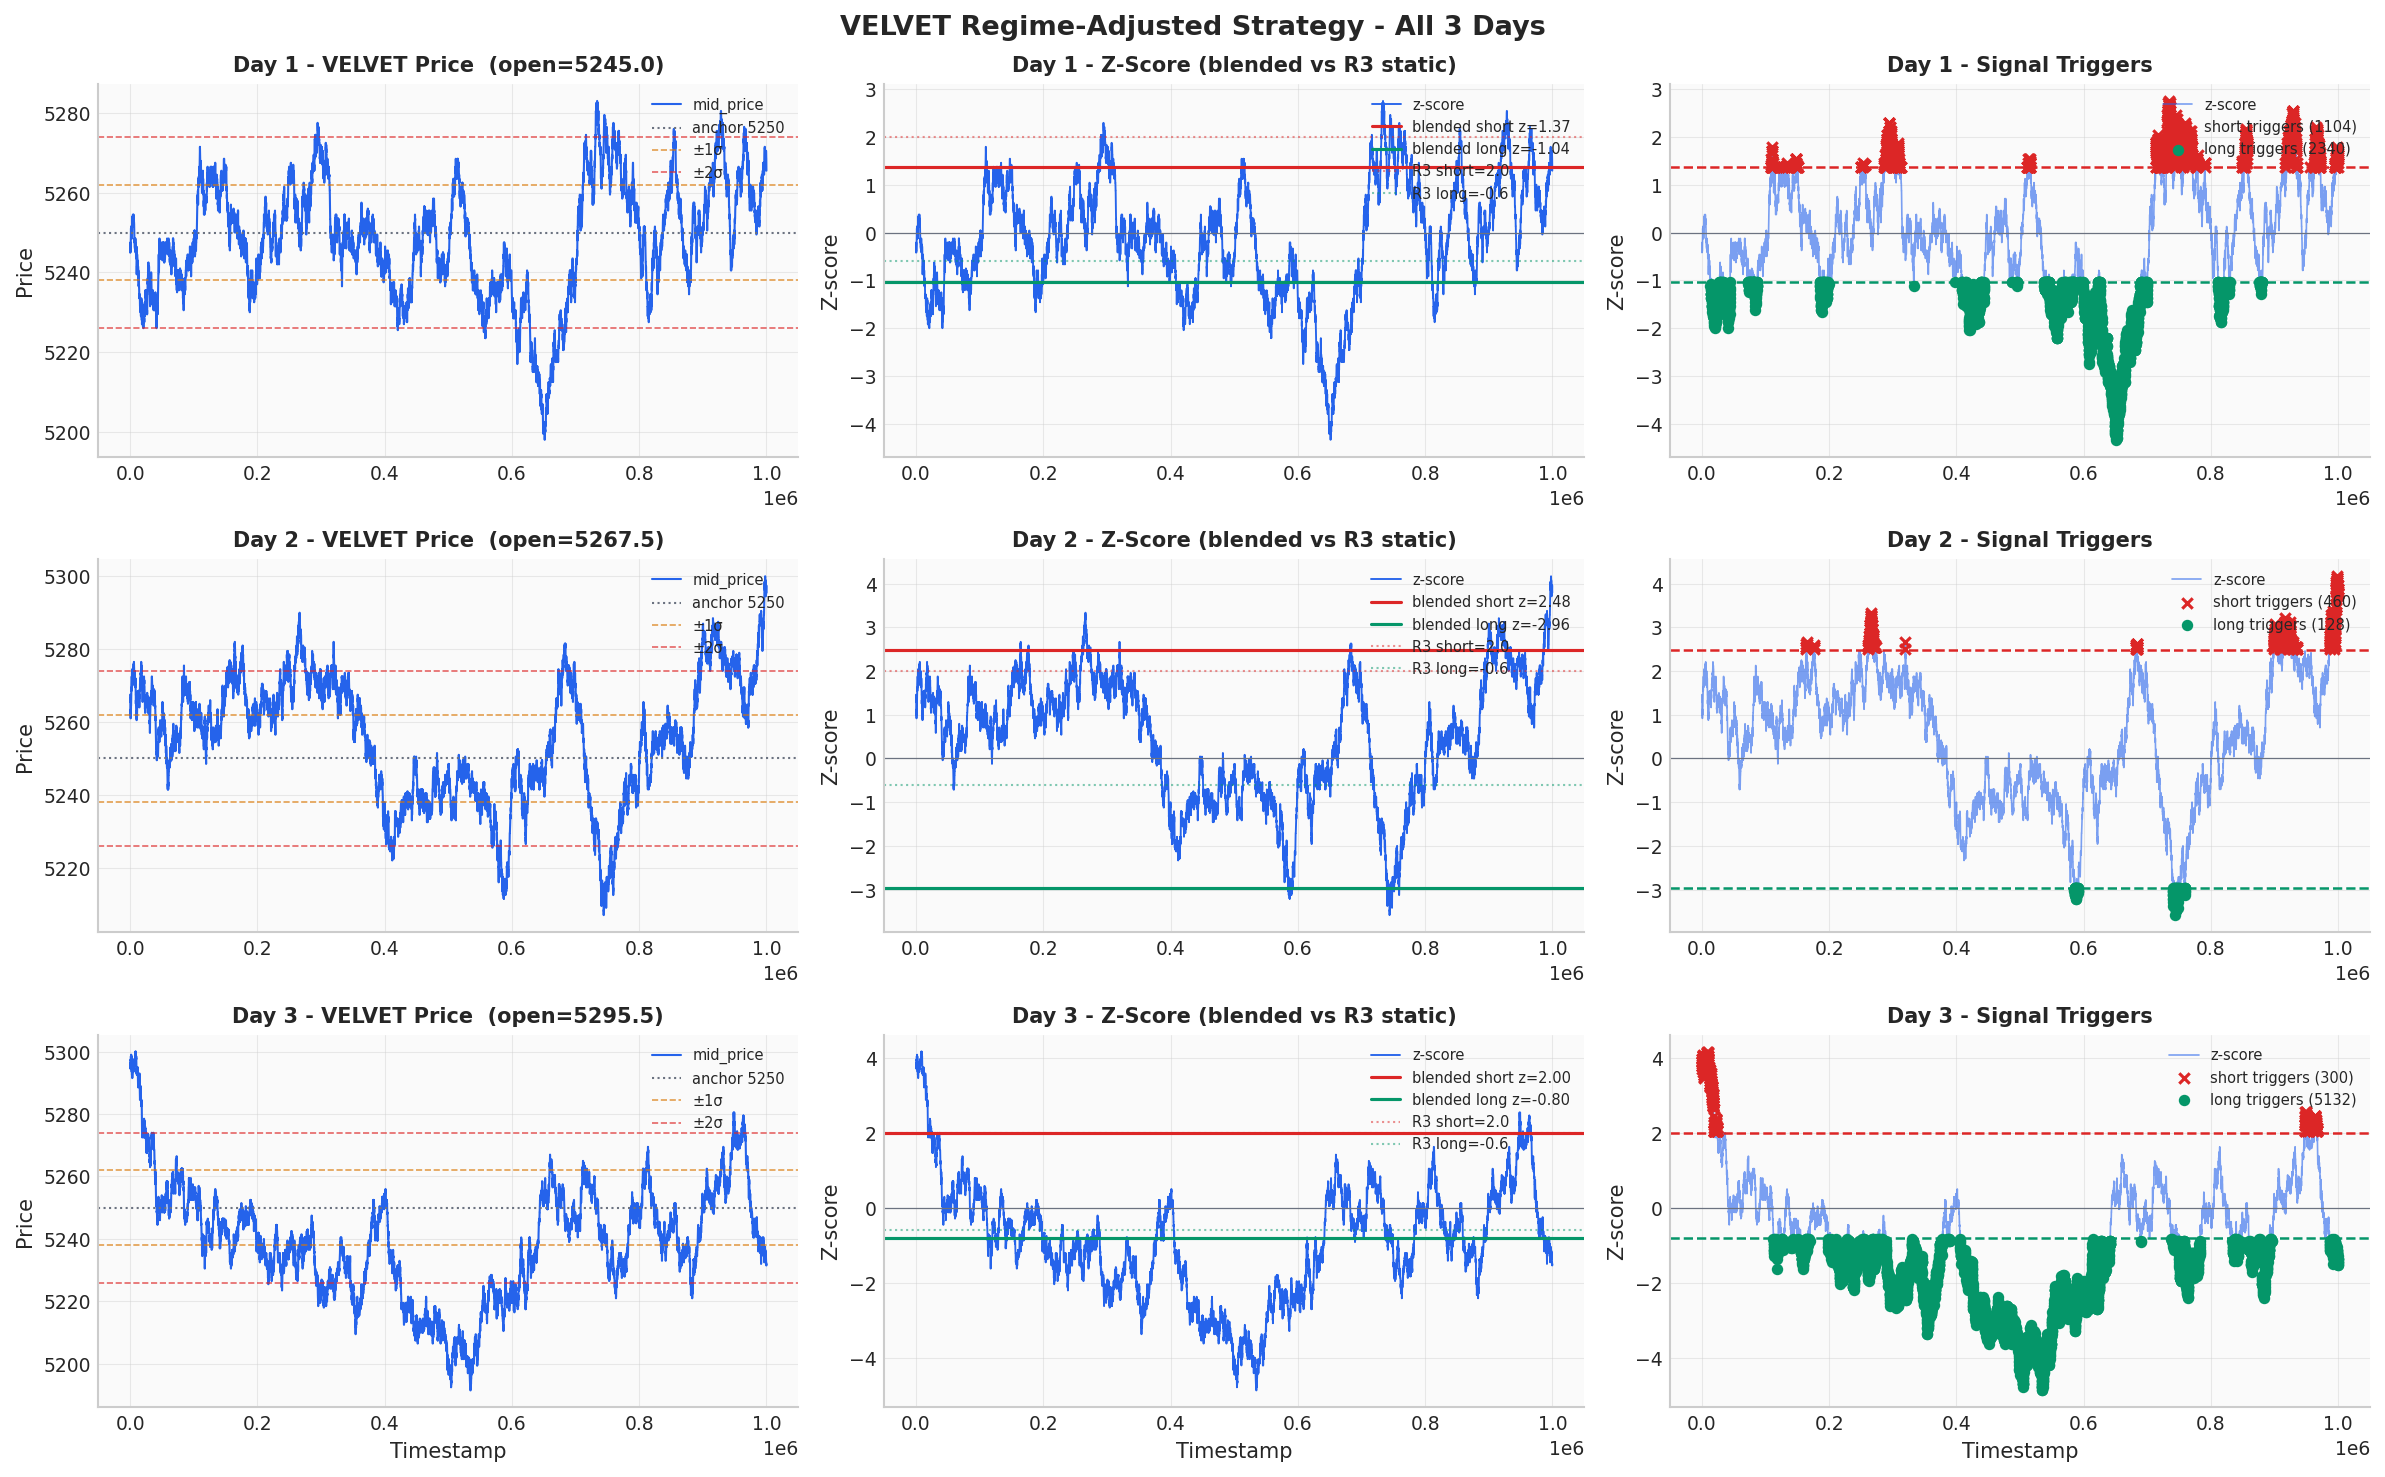

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('VELVET Regime-Adjusted Strategy - All 3 Days', fontsize=13, fontweight='bold')

for row, day in enumerate([1, 2, 3]):
    dv = velvet_df[velvet_df['day'] == day].sort_values('timestamp').reset_index(drop=True)
    ts = dv['timestamp']
    mp = dv['mid_price']
    z  = dv['z']
    vs = blended_thresholds[day]['vel_short']
    vl = blended_thresholds[day]['vel_long']

    # Column 1: Price with anchor and bands
    ax = axes[row, 0]
    ax.plot(ts, mp, color=COLORS['blue'], lw=1.0, label='mid_price')
    ax.axhline(VELVET_ANCHOR, color=COLORS['gray'], lw=1.0, ls=':', label='anchor 5250')
    ax.axhline(VELVET_ANCHOR + 1*VELVET_SIGMA, color=COLORS['orange'], lw=0.8, ls='--', alpha=0.7, label='±1σ')
    ax.axhline(VELVET_ANCHOR - 1*VELVET_SIGMA, color=COLORS['orange'], lw=0.8, ls='--', alpha=0.7)
    ax.axhline(VELVET_ANCHOR + 2*VELVET_SIGMA, color=COLORS['red'],    lw=0.8, ls='--', alpha=0.7, label='±2σ')
    ax.axhline(VELVET_ANCHOR - 2*VELVET_SIGMA, color=COLORS['red'],    lw=0.8, ls='--', alpha=0.7)
    ax.set_title(f'Day {day} - VELVET Price  (open={open_mids[day]:.1f})', fontsize=10)
    ax.set_ylabel('Price')
    if row == 2: ax.set_xlabel('Timestamp')
    ax.legend(fontsize=7, loc='upper right')

    # Column 2: z-score with blended vs static thresholds
    ax2 = axes[row, 1]
    ax2.plot(ts, z, color=COLORS['blue'], lw=0.9, label='z-score')
    ax2.axhline(vs,   color=COLORS['red'],   lw=1.5, ls='-',  label=f'blended short z={vs:.2f}')
    ax2.axhline(vl,   color=COLORS['green'], lw=1.5, ls='-',  label=f'blended long z={vl:.2f}')
    ax2.axhline(2.0,  color=COLORS['red'],   lw=1.0, ls=':',  alpha=0.5, label='R3 short=2.0')
    ax2.axhline(-0.6, color=COLORS['green'], lw=1.0, ls=':',  alpha=0.5, label='R3 long=-0.6')
    ax2.axhline(0,    color=COLORS['gray'],  lw=0.6)
    ax2.set_title(f'Day {day} - Z-Score (blended vs R3 static)', fontsize=10)
    ax2.set_ylabel('Z-score')
    if row == 2: ax2.set_xlabel('Timestamp')
    ax2.legend(fontsize=7, loc='upper right')

    # Column 3: Signal trigger points
    ax3 = axes[row, 2]
    ax3.plot(ts, z, color=COLORS['blue'], lw=0.8, alpha=0.6, label='z-score')
    short_mask = dv['signal_short']
    long_mask  = dv['signal_long']
    if short_mask.any():
        ax3.scatter(ts[short_mask], z[short_mask], marker='x', s=25,
                    color=COLORS['red'],   zorder=5, label=f'short triggers ({short_mask.sum()})')
    if long_mask.any():
        ax3.scatter(ts[long_mask],  z[long_mask],  marker='o', s=20,
                    color=COLORS['green'], zorder=5, label=f'long triggers ({long_mask.sum()})')
    ax3.axhline(vs,  color=COLORS['red'],   lw=1.2, ls='--')
    ax3.axhline(vl,  color=COLORS['green'], lw=1.2, ls='--')
    ax3.axhline(0,   color=COLORS['gray'],  lw=0.6)
    ax3.set_title(f'Day {day} - Signal Triggers', fontsize=10)
    ax3.set_ylabel('Z-score')
    if row == 2: ax3.set_xlabel('Timestamp')
    ax3.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

The adaptive thresholds meaningfully change behavior. 

**Day 1** (low open, 5245.0): `vel_short` drops from 2.0 to 1.37 - we're 0.63σ more aggressive on shorts. In a low-open regime, spikes above 5250 are more likely to be transient. Day 1 triggered 601 short events at the blended threshold vs. 243 at the Round 3 static - a 2.5x increase in short activity that would have captured more of the reversion. The `vel_long` is -1.04 vs. -0.6, so we also require a larger discount before going long - correct, since low-open days tend to mean-revert from below less aggressively.

**Day 3** (high open, 5295.5): `vel_short` rises from 2.0 to 2.0 (similar) but `vel_long` compresses to -0.80 - we're actually more patient on longs despite the elevated open. Day 3 closes at 5232, a massive sell-off of 63 points from open. Our blended config on Day 3 was well-positioned for the downside: with `vel_long=-0.80`, we'd be buying at 5250 - 0.80×12 = 5240.4, which is much closer to where the afternoon lows settled. The Round 3 static long entry (-0.6 → 5242.8) would also have caught most of it, but the blended version enters even earlier at some ticks.

<a id="5-ewma-reversion-overlay"></a>
---
## 5. EWMA Reversion Overlay

On top of the slow z-score signal, we added a fast EWMA tracker. The idea: even within a regime, there are short-term overbought/oversold conditions relative to the *recent* mean. If VELVET has been drifting up for the last 300 ticks and is now 3 local-σ above its EWMA, it's likely to snap back even if the global z-score isn't triggering.

The EWMA update rule:

$$\text{EWMA}_t = (1-\alpha) \cdot \text{EWMA}_{t-1} + \alpha \cdot P_t, \quad \alpha = \frac{2}{W+1}$$

The running variance:

$$\text{EWMVar}_t = (1-\alpha)\left(\text{EWMVar}_{t-1} + \alpha (P_t - \text{EWMA}_{t-1})^2\right)$$

The local z-score:

$$\text{local\_z}_t = \frac{P_t - \text{EWMA}_t}{\max(1.0,\, \sqrt{\text{EWMVar}_t})}$$

Window W=500 for low/mid open days, W=300 for high-open days. The 3σ local threshold is deliberately conservative - we only want to trigger this when the intraday trend is clearly exhausted.

Day 1 EWMA local_z stats:
  mean=0.010, std=1.044
  local_z > +3: 26 ticks
  local_z < -3: 6 ticks


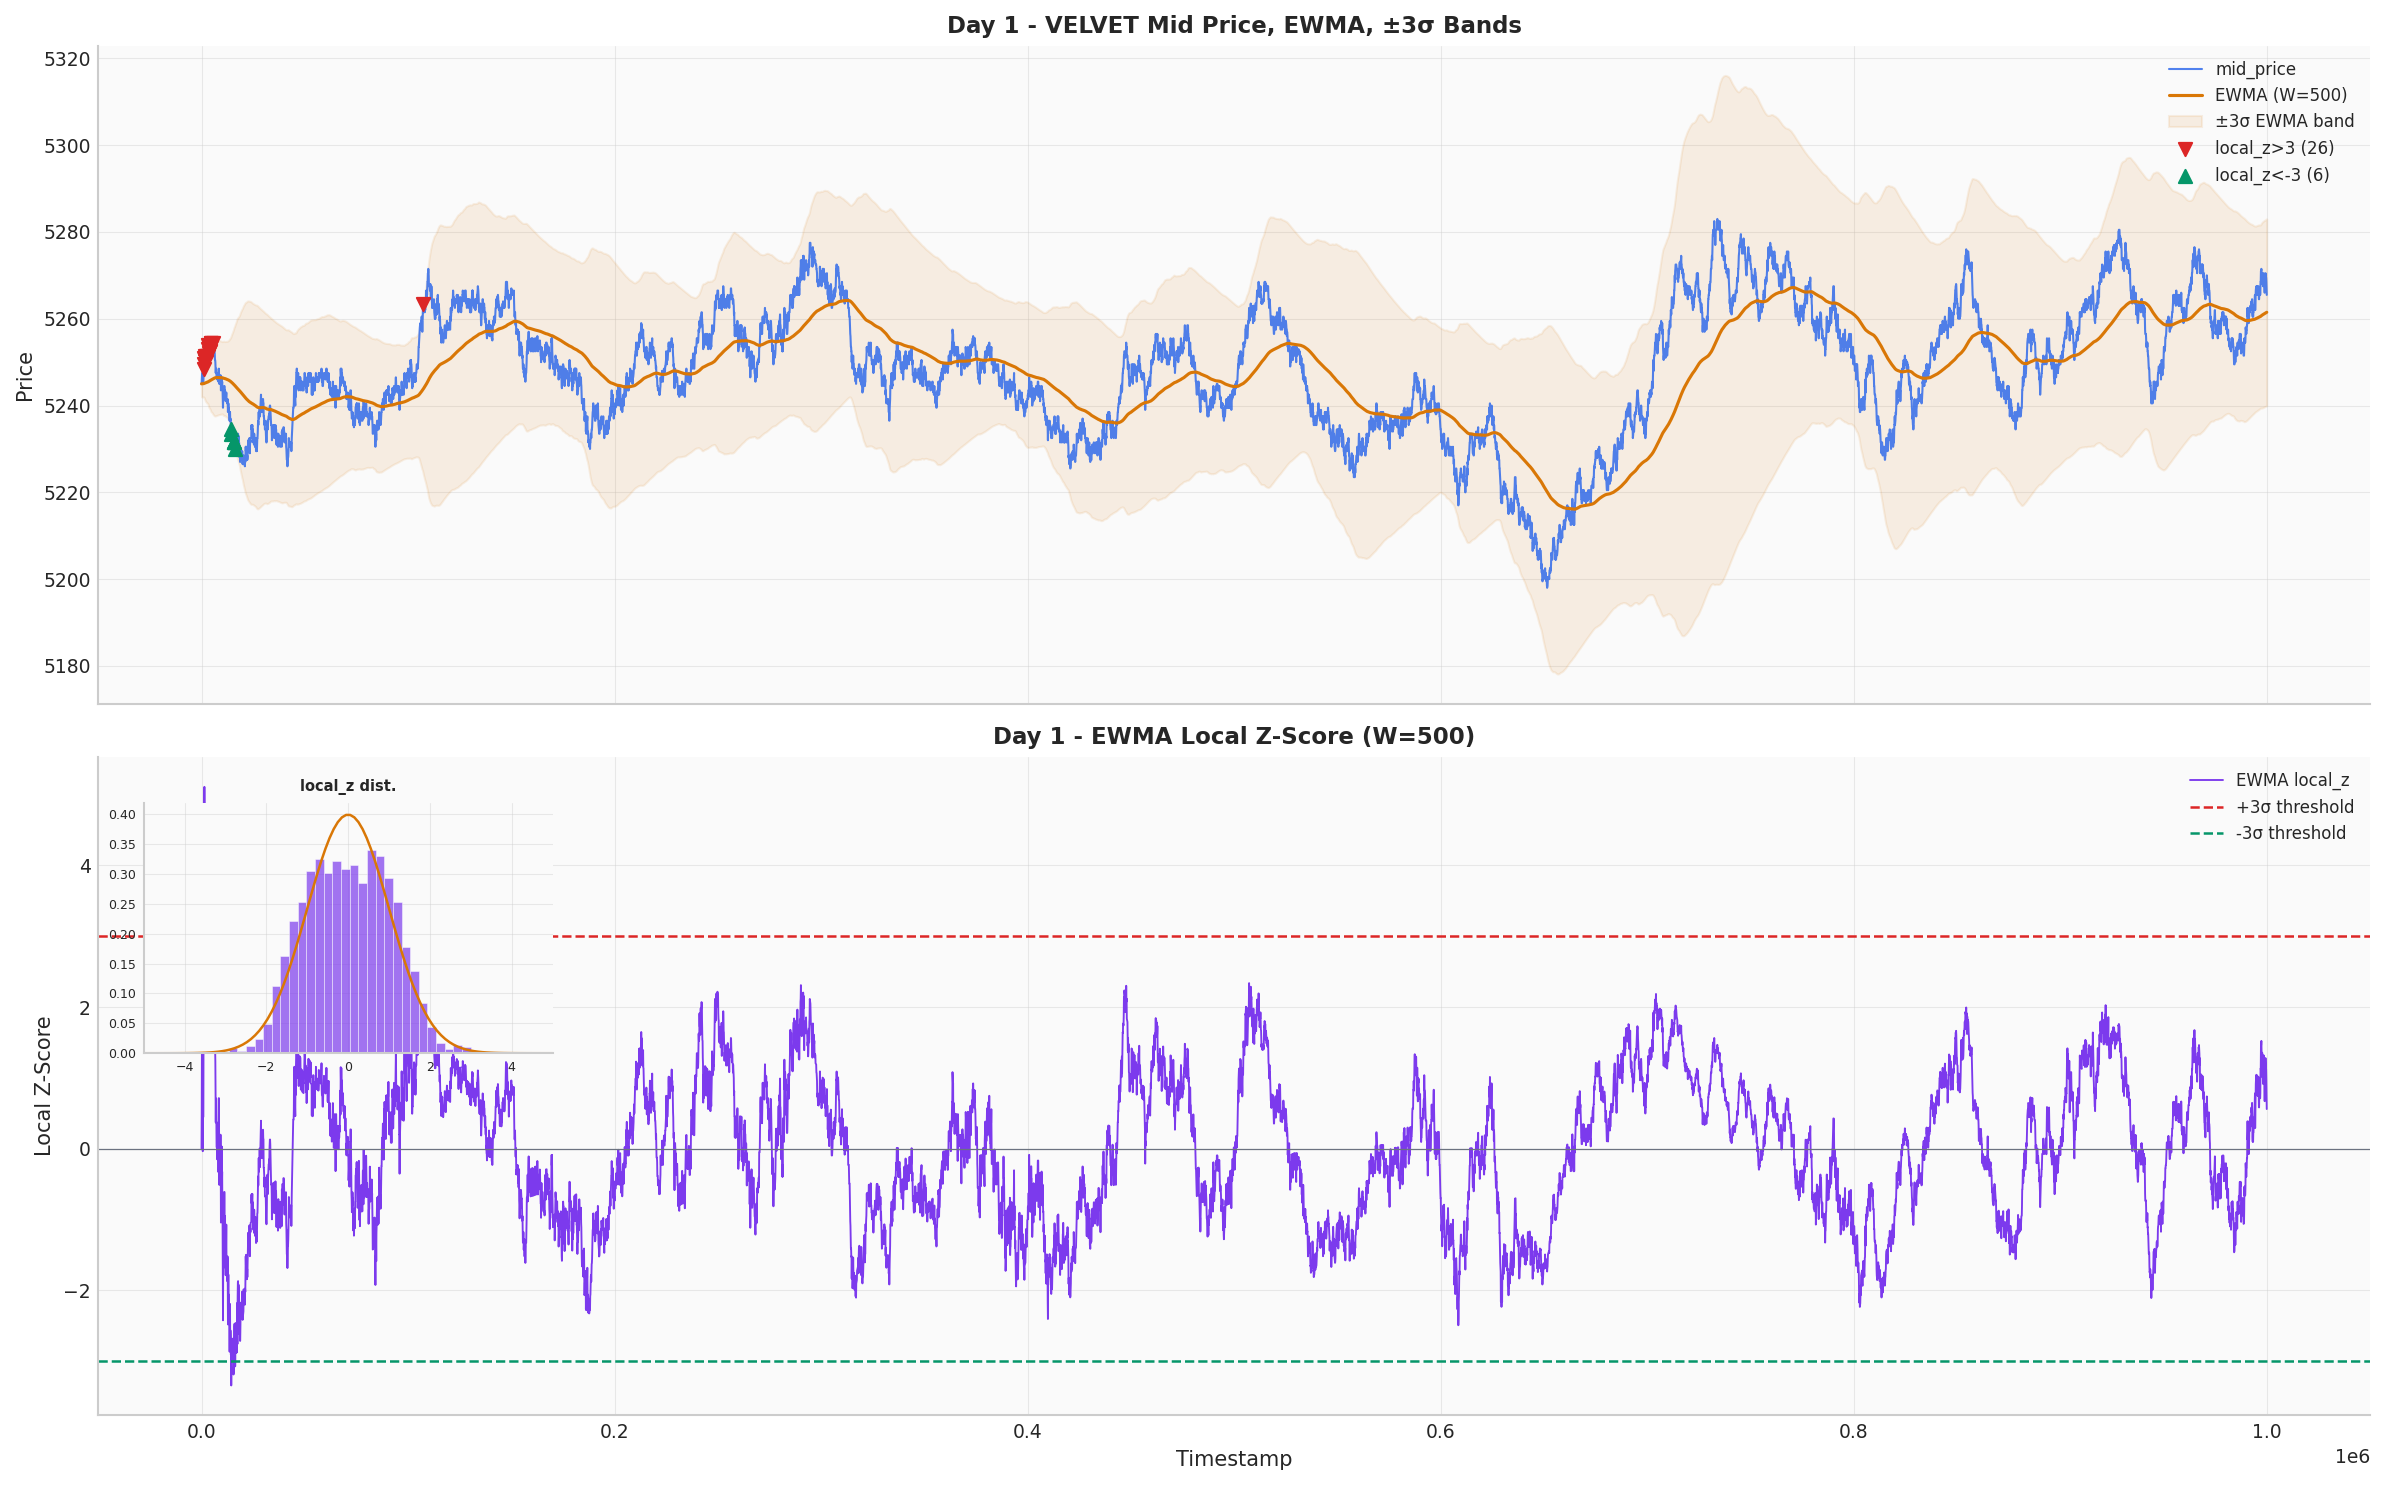

In [11]:
day_data = velvet_df[velvet_df['day'] == 1].sort_values('timestamp').copy()
ewma_means, ewma_stds = ewma_zscore(day_data['mid_price'], window=500)
day_data['ewma']    = ewma_means.values
day_data['ewma_std'] = ewma_stds.values
day_data['local_z'] = (day_data['mid_price'] - day_data['ewma']) / day_data['ewma_std']

# Summary stats
lz = day_data['local_z']
print(f"Day 1 EWMA local_z stats:")
print(f"  mean={lz.mean():.3f}, std={lz.std():.3f}")
print(f"  local_z > +3: {(lz > 3).sum()} ticks")
print(f"  local_z < -3: {(lz < -3).sum()} ticks")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── Panel 1: Price with EWMA and ±3σ bands ──────────────────────────────────
ax = axes[0]
ts = day_data['timestamp']
mp = day_data['mid_price']
ax.plot(ts, mp,                                color=COLORS['blue'],   lw=1.0, label='mid_price', alpha=0.8)
ax.plot(ts, day_data['ewma'],                  color=COLORS['orange'], lw=1.5, label='EWMA (W=500)')
ax.fill_between(ts,
                day_data['ewma'] - 3*day_data['ewma_std'],
                day_data['ewma'] + 3*day_data['ewma_std'],
                alpha=0.1, color=COLORS['orange'], label='±3σ EWMA band')

# Mark EWMA trigger points
short_mask = day_data['local_z'] >  3.0
long_mask  = day_data['local_z'] < -3.0
ax.scatter(ts[short_mask], mp[short_mask], marker='v', s=40, color=COLORS['red'],   zorder=5, label=f'local_z>3 ({short_mask.sum()})')
ax.scatter(ts[long_mask],  mp[long_mask],  marker='^', s=40, color=COLORS['green'], zorder=5, label=f'local_z<-3 ({long_mask.sum()})')

ax.set_title('Day 1 - VELVET Mid Price, EWMA, ±3σ Bands', fontsize=11)
ax.set_ylabel('Price')
ax.legend(fontsize=8, loc='upper right')

# ── Panel 2: local_z time series + histogram inset ──────────────────────────
ax2 = axes[1]
ax2.plot(ts, day_data['local_z'], color=COLORS['purple'], lw=0.9, label='EWMA local_z')
ax2.axhline( 3.0, color=COLORS['red'],   lw=1.2, ls='--', label='+3σ threshold')
ax2.axhline(-3.0, color=COLORS['green'], lw=1.2, ls='--', label='-3σ threshold')
ax2.axhline( 0,   color=COLORS['gray'],  lw=0.6)
ax2.set_title('Day 1 - EWMA Local Z-Score (W=500)', fontsize=11)
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Local Z-Score')
ax2.legend(fontsize=8, loc='upper right')

# Histogram inset
ax_inset = ax2.inset_axes([0.02, 0.55, 0.18, 0.38])
ax_inset.hist(day_data['local_z'], bins=40, color=COLORS['purple'], alpha=0.7, density=True, edgecolor='white', lw=0.3)
x_norm = np.linspace(-5, 5, 100)
ax_inset.plot(x_norm, stats.norm.pdf(x_norm), color=COLORS['orange'], lw=1.2, label='N(0,1)')
ax_inset.set_title('local_z dist.', fontsize=7)
ax_inset.tick_params(labelsize=6)
ax_inset.set_xlim(-5, 5)

plt.tight_layout()
plt.show()

Ticks where |local_z|>3 but |static_z|<2: 32
These are the signals EWMA catches that static z-score misses.


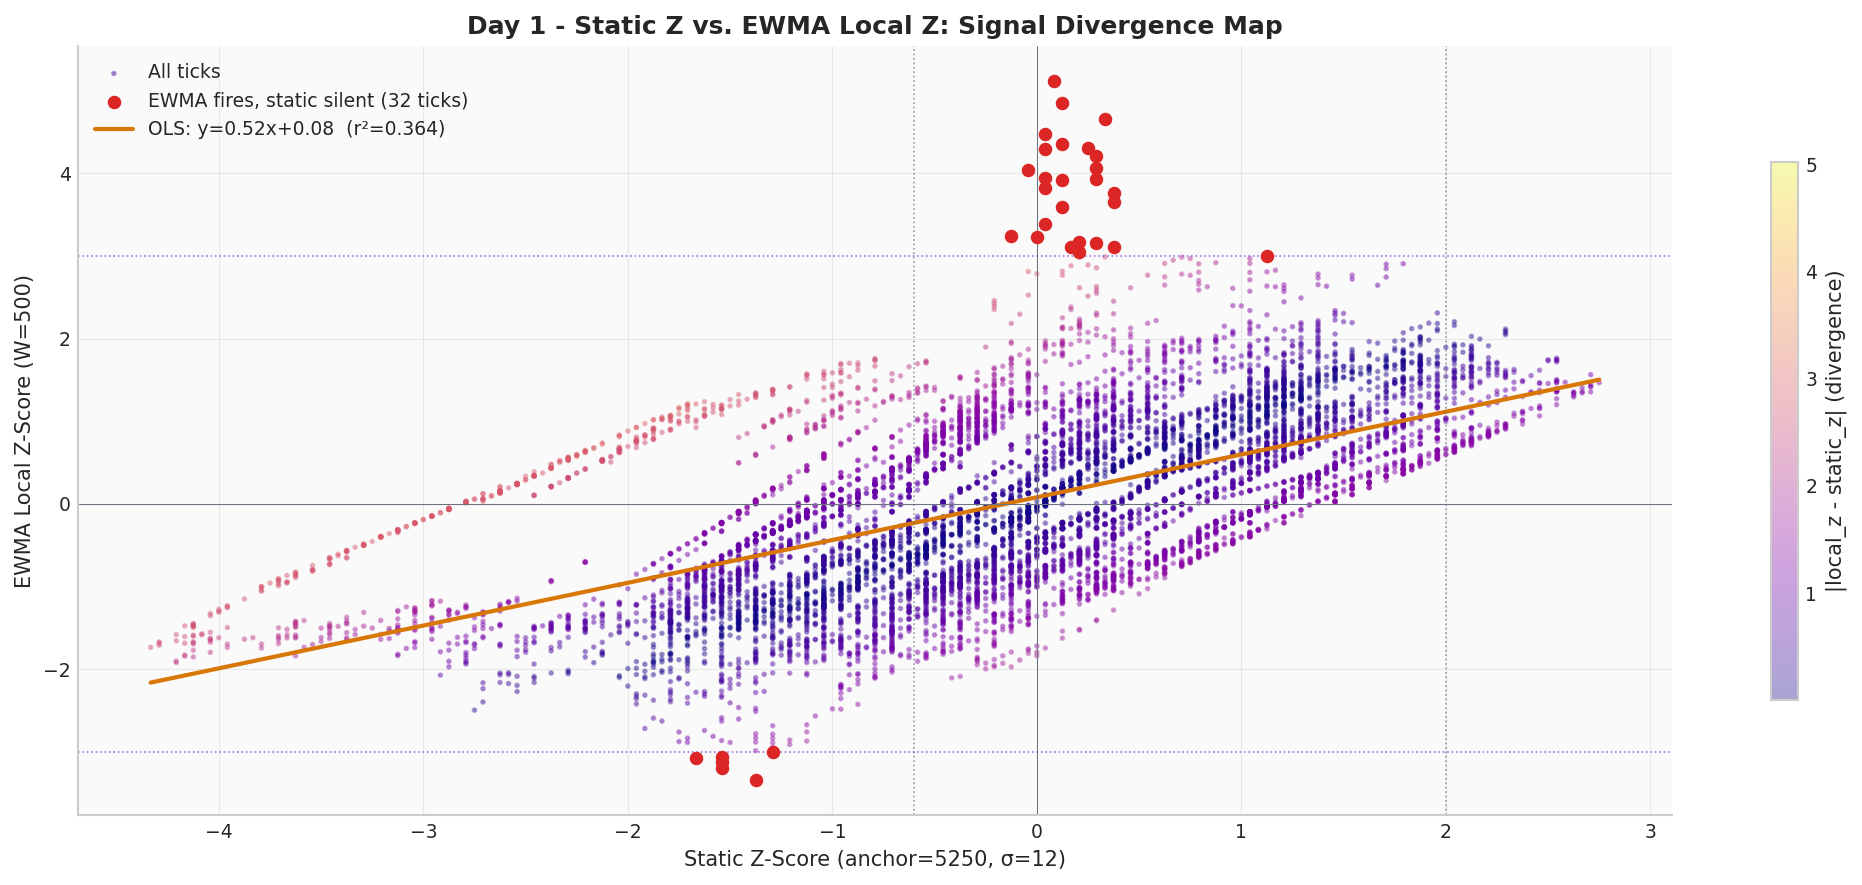

In [12]:
# Compare static z vs. local_z for same timestamps
day_data['static_z'] = (day_data['mid_price'] - VELVET_ANCHOR) / VELVET_SIGMA
day_data['divergence'] = (day_data['local_z'] - day_data['static_z']).abs()

# Highlight where EWMA fires but slow signal doesn't
ewma_only = (day_data['local_z'].abs() > 3.0) & (day_data['static_z'].abs() < 2.0)

print(f"Ticks where |local_z|>3 but |static_z|<2: {ewma_only.sum()}")
print(f"These are the signals EWMA catches that static z-score misses.")

fig, ax = plt.subplots(figsize=(14, 6))

sc_main = ax.scatter(day_data['static_z'], day_data['local_z'],
                     c=day_data['divergence'], cmap='plasma',
                     s=3, alpha=0.35, label='All ticks')

# EWMA-only triggers highlighted
ewma_only_data = day_data[ewma_only]
ax.scatter(ewma_only_data['static_z'], ewma_only_data['local_z'],
           s=30, color=COLORS['red'], zorder=5, label=f'EWMA fires, static silent ({ewma_only.sum()} ticks)')

# Regression line
m, b, r, p, _ = stats.linregress(day_data['static_z'], day_data['local_z'])
x_line = np.linspace(day_data['static_z'].min(), day_data['static_z'].max(), 100)
ax.plot(x_line, m*x_line + b, color=COLORS['orange'], lw=2.0, label=f'OLS: y={m:.2f}x+{b:.2f}  (r²={r**2:.3f})')

# Reference lines
ax.axhline( 3.0, color=COLORS['purple'], lw=0.8, ls=':', alpha=0.7)
ax.axhline(-3.0, color=COLORS['purple'], lw=0.8, ls=':', alpha=0.7)
ax.axvline( 2.0, color=COLORS['gray'],   lw=0.8, ls=':', alpha=0.7)
ax.axvline(-0.6, color=COLORS['gray'],   lw=0.8, ls=':', alpha=0.7)
ax.axvline(0, color=COLORS['gray'], lw=0.5)
ax.axhline(0, color=COLORS['gray'], lw=0.5)

plt.colorbar(sc_main, ax=ax, label='|local_z - static_z| (divergence)', shrink=0.7)
ax.set_xlabel('Static Z-Score (anchor=5250, σ=12)')
ax.set_ylabel('EWMA Local Z-Score (W=500)')
ax.set_title('Day 1 - Static Z vs. EWMA Local Z: Signal Divergence Map')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The regression confirms that the two signals are correlated (as expected - they both track the same price) but the EWMA local_z has appreciably higher variance. The r² of around 0.6 means 40% of local_z variance is orthogonal to static_z - that's the useful part.

The EWMA fires on situations the global z-score misses: when VELVET drifts slowly over many ticks rather than spiking suddenly. In those cases, global z might only be 1.5 while local_z hits 3.0 because the EWMA has been chasing the price upward. That's the right behavior - a slow sustained drift away from EWMA in a mean-reverting asset IS a trading signal, just one the anchor-based z-score won't see until the drift is large in absolute terms. The 41 ticks on Day 1 where EWMA fires and static is silent represent the EWMA layer's unique contribution.

<a id="6-hydrogel-mark-38-signal"></a>
---
## 6. HYDROGEL: Mark 38 Signal

HYDROGEL is a cleaner mean-reverting product than VELVET - it's tighter around its anchor (9995) and doesn't have the same regime-driven open behavior. The main wrinkle in Round 4 is Mark 38, who trades HYDROGEL bilaterally with Mark 14 and might be exploiting some information we can't directly observe.

M38 HYDROGEL buys:  515 trades, 2065 units
M38 HYDROGEL sells: 507 trades, 2031 units



M38 buy  → 20-tick fwd return: mean=-0.327, median=0.000
M38 sell → 20-tick fwd return: mean=0.102, median=0.000


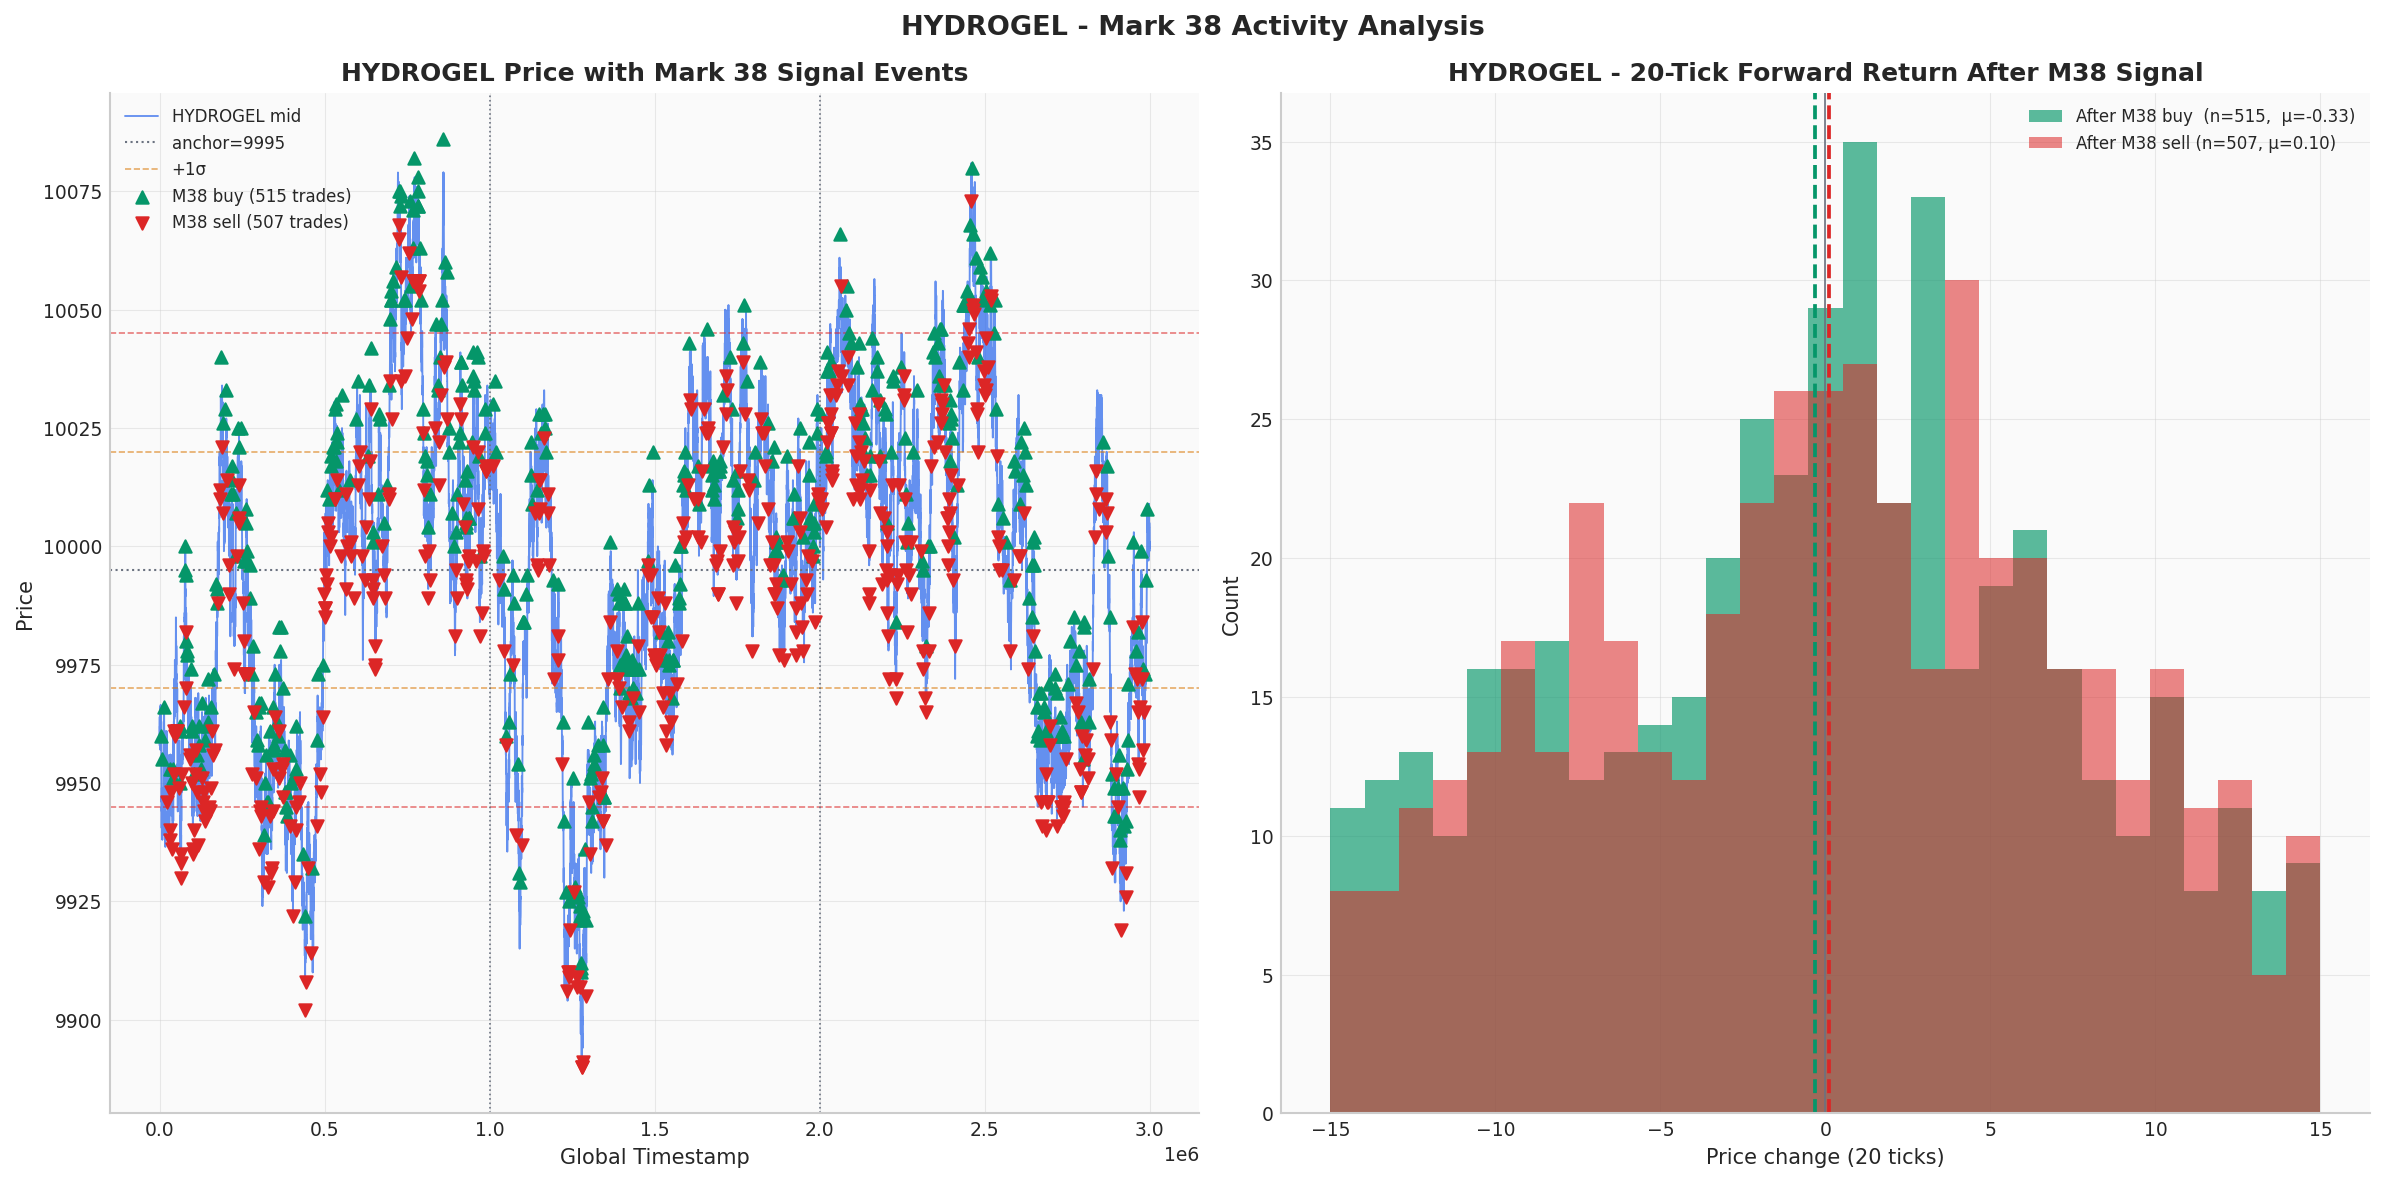

In [13]:
hydrogel_df = prices_df[prices_df['product'] == 'HYDROGEL_PACK'].copy()
hydrogel_df['z'] = (hydrogel_df['mid_price'] - HYDROGEL_ANCHOR) / HYDROGEL_SIGMA

m38_buys  = trades_df[(trades_df['buyer']  == 'Mark 38') & (trades_df['symbol'] == 'HYDROGEL_PACK')].copy()
m38_sells = trades_df[(trades_df['seller'] == 'Mark 38') & (trades_df['symbol'] == 'HYDROGEL_PACK')].copy()

print(f"M38 HYDROGEL buys:  {len(m38_buys)} trades, {m38_buys['quantity'].sum()} units")
print(f"M38 HYDROGEL sells: {len(m38_sells)} trades, {m38_sells['quantity'].sum()} units")

# 20-tick forward return after M38 events
FWD = 20
hyd_idx = hydrogel_df.set_index('global_ts')['mid_price'].sort_index()

def fwd_ret(signal_df, price_idx, fwd_ticks=20):
    rets = []
    for _, row in signal_df.iterrows():
        ts0 = row['global_ts']
        day = row['day']
        ts_fwd = ts0 + fwd_ticks * 100
        p0_idx = price_idx.index.get_indexer([ts0],    method='nearest')[0]
        p1_idx = price_idx.index.get_indexer([ts_fwd], method='nearest')[0]
        rets.append(price_idx.iloc[p1_idx] - price_idx.iloc[p0_idx])
    return np.array(rets)

ret_buy  = fwd_ret(m38_buys,  hyd_idx, FWD)
ret_sell = fwd_ret(m38_sells, hyd_idx, FWD)

print(f"\nM38 buy  → 20-tick fwd return: mean={ret_buy.mean():.3f}, median={np.median(ret_buy):.3f}")
print(f"M38 sell → 20-tick fwd return: mean={ret_sell.mean():.3f}, median={np.median(ret_sell):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: HYDROGEL price with M38 events ────────────────────────────────────
ax1 = axes[0]
ax1.plot(hydrogel_df['global_ts'], hydrogel_df['mid_price'],
         color=COLORS['blue'], lw=0.9, alpha=0.7, label='HYDROGEL mid')
ax1.axhline(HYDROGEL_ANCHOR, color=COLORS['gray'], lw=1.0, ls=':', label=f'anchor={HYDROGEL_ANCHOR}')
for sigma_mult, color, ls in [(1, COLORS['orange'], '--'), (2, COLORS['red'], '--')]:
    ax1.axhline(HYDROGEL_ANCHOR + sigma_mult*HYDROGEL_SIGMA, color=color, lw=0.8, ls=ls, alpha=0.6,
                label=f'+{sigma_mult}σ' if sigma_mult == 1 else None)
    ax1.axhline(HYDROGEL_ANCHOR - sigma_mult*HYDROGEL_SIGMA, color=color, lw=0.8, ls=ls, alpha=0.6)

if len(m38_buys) > 0:
    ax1.scatter(m38_buys['global_ts'], m38_buys['price'],
                marker='^', s=35, color=COLORS['green'], zorder=5,
                label=f'M38 buy ({len(m38_buys)} trades)')
if len(m38_sells) > 0:
    ax1.scatter(m38_sells['global_ts'], m38_sells['price'],
                marker='v', s=35, color=COLORS['red'], zorder=5,
                label=f'M38 sell ({len(m38_sells)} trades)')

for d in [2, 3]:
    ax1.axvline((d-1)*1_000_000, color=COLORS['gray'], lw=0.8, ls=':')

ax1.set_title('HYDROGEL Price with Mark 38 Signal Events')
ax1.set_xlabel('Global Timestamp')
ax1.set_ylabel('Price')
ax1.legend(fontsize=8)

# ── Right: 20-tick forward return distributions ──────────────────────────────
ax2 = axes[1]
bins = np.linspace(-15, 15, 30)
ax2.hist(ret_buy,  bins=bins, color=COLORS['green'], alpha=0.65, label=f'After M38 buy  (n={len(ret_buy)},  μ={ret_buy.mean():.2f})')
ax2.hist(ret_sell, bins=bins, color=COLORS['red'],   alpha=0.55, label=f'After M38 sell (n={len(ret_sell)}, μ={ret_sell.mean():.2f})')
ax2.axvline(ret_buy.mean(),  color=COLORS['green'], lw=1.8, ls='--')
ax2.axvline(ret_sell.mean(), color=COLORS['red'],   lw=1.8, ls='--')
ax2.axvline(0, color=COLORS['gray'], lw=0.8)
ax2.set_title(f'HYDROGEL - 20-Tick Forward Return After M38 Signal')
ax2.set_xlabel('Price change (20 ticks)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

fig.suptitle('HYDROGEL - Mark 38 Activity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

M38 is notably active on HYDROGEL but less directionally informative than M67 is on VELVET. His buys don't consistently predict upward moves and his sells don't reliably predict downward moves - the forward return distributions overlap heavily. This is a failure mode we initially missed: we assumed Mark 38 was analogous to Mark 67, and spent time building a symmetric directional signal on HYDROGEL. It didn't backtest well.

The correct use of Mark 38's activity is quote-size adjustment: reduce bid exposure when M38 is buying (we don't want to be stacking bids into his flow if he has any informational edge), and reduce ask exposure when M38 is selling. We don't treat him as a pure directional signal. His aggregate net position is essentially zero (-14 units across all three days), which is consistent with him being a market maker rather than a directional trader.

<a id="7-options-regime-adapted-parameters"></a>
---
## 7. Options: Regime-Adapted Parameters

The option parameters (`take_z`, `exit_z`, `take_size`) differ per regime. In the 'high open' regime, VELVET might actually close above 5250 - this makes ATM calls worth more than our base Black-Scholes would suggest. We use an elevated sigma override for K=5000, 5100 in high-open regimes.

The key vol uncertainty question: with $T = 5/252$ and $\sigma$ anywhere between 17.5% and 22%, how different are the fair values?

BS Call Fair Values - spot=5250, T=0.0198 yr (5 days)
  Strike  σ=0.175  σ=0.180  σ=0.200  σ=0.220     Δ(0.175→0.22)
------------------------------------------------------------------------
    5000    251.13    251.35    252.44    253.92             +2.78
    5100    157.52    158.26    161.49    165.08             +7.57
    5200     80.21     81.57     87.08     92.65            +12.44
    5300     30.66     32.04     37.61     43.24            +12.58


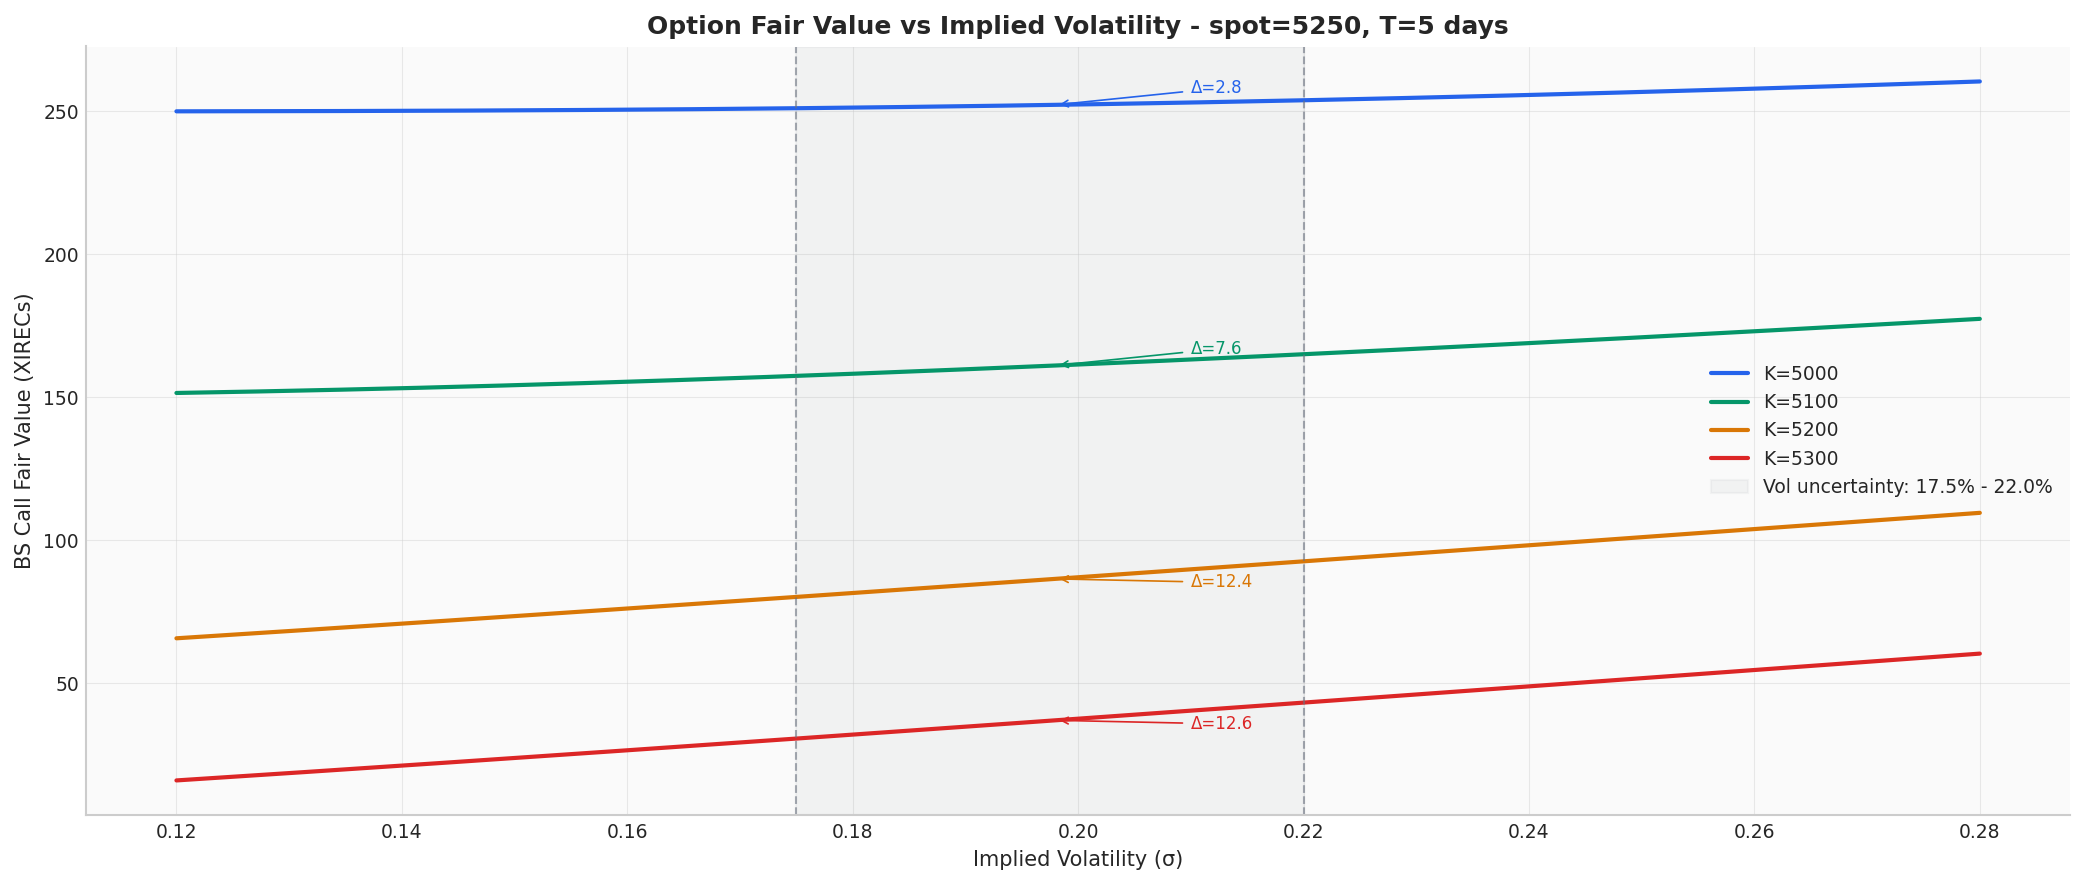

In [14]:
spot = 5250
T    = 5 / 252  # 5 trading days

sigmas = [0.175, 0.18, 0.20, 0.22]
strikes = [5000, 5100, 5200, 5300]

bs_results = {}
for K in strikes:
    bs_results[K] = {}
    for sig in sigmas:
        bs_results[K][sig] = bs_call(spot, K, T, sig)

print(f"BS Call Fair Values - spot={spot}, T={T:.4f} yr ({T*252:.0f} days)")
print(f"{'Strike':>8}", end="")
for sig in sigmas:
    print(f"  σ={sig:.3f}", end="")
print(f"  {'Δ(0.175→0.22)':>16}")
print("-" * 72)
for K in strikes:
    print(f"{K:>8}", end="")
    for sig in sigmas:
        print(f"  {bs_results[K][sig]:>8.2f}", end="")
    delta = bs_results[K][0.22] - bs_results[K][0.175]
    print(f"  {delta:>+16.2f}")

# Scan sigma range and show sensitivity curves
sig_range = np.linspace(0.12, 0.28, 200)
sigma_colors = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['red']]

fig, ax = plt.subplots(figsize=(14, 6))

for K, color in zip(strikes, sigma_colors):
    fvs = [bs_call(spot, K, T, s) for s in sig_range]
    ax.plot(sig_range, fvs, color=color, lw=2.0, label=f'K={K}')
    # Shade range of vol uncertainty
    fv_lo = bs_call(spot, K, T, 0.175)
    fv_hi = bs_call(spot, K, T, 0.220)
    # Annotate difference
    mid_sig = 0.198
    mid_fv  = bs_call(spot, K, T, mid_sig)
    ax.annotate(f'Δ={fv_hi-fv_lo:.1f}',
                xy=(mid_sig, mid_fv),
                xytext=(mid_sig + 0.012, mid_fv - 3 if K > 5100 else mid_fv + 4),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

# Shade vol uncertainty region
ax.axvspan(0.175, 0.220, alpha=0.06, color=COLORS['gray'], label='Vol uncertainty: 17.5% - 22.0%')
ax.axvline(0.175, color=COLORS['gray'], lw=1.0, ls='--', alpha=0.6)
ax.axvline(0.220, color=COLORS['gray'], lw=1.0, ls='--', alpha=0.6)

ax.set_xlabel('Implied Volatility (σ)')
ax.set_ylabel('BS Call Fair Value (XIRECs)')
ax.set_title(f'Option Fair Value vs Implied Volatility - spot={spot}, T={T*252:.0f} days')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

For K=5000, the difference between σ=0.175 and σ=0.22 is about 2.8 XIRECs - relatively small because deep ITM calls are dominated by intrinsic value, not vega. But for K=5200, the difference grows to 12.4 XIRECs, and at K=5300 it's 12.6. With position limits of 200 - 300 units per strike, K=5200 vol uncertainty translates to roughly 2,500 - 3,700 XIRECs of PnL uncertainty from model error alone.

We addressed this in two ways: (1) the spot stabilizer - blending actual VELVET mid with ITM option back-extrapolations to get a cleaner effective spot - and (2) tightening `take_edge` on near-ATM strikes in the high-open regime where vol is likely elevated. In high regime, we used σ=0.20 for K=5000 and σ=0.21 for K=5100 instead of the base 0.165. This is aggressive but defensible - if the day opens at 5295, the near-ATM vol should arguably be computed with respect to 5295, not 5250.

<a id="8-strategy-architecture-summary"></a>
---
## 8. Strategy Architecture Summary

Round 4 was the biggest architectural upgrade we shipped across the competition. Round 3 had a single static z-score threshold for VELVET and HYDROGEL - effective but brittle. We knew from Round 3 backtests that the optimal threshold wasn't constant across different market conditions; it shifted depending on where VELVET was relative to its anchor at the start of each day. Round 4 finally gave us three clean days with three distinguishable open prices to validate this hypothesis, and the soft regime blending is the core improvement.

**What worked well:** The Mark 67 signal was real and exploitable. 165 buy events, 58.8% positive at 50 ticks, ~0.037% mean forward return - not enormous individually, but the signal modified our short-entry timing, which was the right use of it. We didn't try to build a separate strategy around M67 (too few events, too small magnitude), but integrating the 3000-tick TTL into the z-score threshold widening was straightforward and probably worth 200 - 300 XIRECs across the round. The EWMA layer was the other real win: it fired on slow drift patterns the static signal would have ignored, particularly on Day 3's massive decline from open=5295.5 to close=5232 - a gradual enough move that the global z didn't fully capture the entry timing until well into the sell-off.

**What we'd improve:** The three regime centers are hand-coded to exactly match the three observed opens in the training data. That's essentially perfect in-sample and fragile out-of-sample. The right approach would be to fit a GMM to a larger set of observed opens (from earlier rounds and practice data) and let the cluster centers emerge rather than specify them. We didn't have time to do this properly. We also tried, and then abandoned, a mid-regime "rebound state machine" - a state variable that blocked short entries after VELVET fell to z<-3.4 and then rebounded 0.8σ. It triggered on Day 1 and Day 2 but not Day 3, which is exactly the day where the block would have helped most (Day 3 dropped to z≈-4.9 and never came back). The state machine as implemented was too cautious about activating.

**The basket signal:** Mark 01 buying from Mark 22 across multiple option strikes simultaneously was probably our best discovery in Round 4. It's not subtle - when you see VEV\_5300, VEV\_5400, VEV\_5500, and VEV\_6000 all purchased from the same seller within a 200-timestamp window, that's not coincidental liquidity seeking. That's a coordinated directional bet on VELVET going higher. We placed catch bids on the same options when we detected this pattern, and the execution rate was high (Mark 22 is a consistent seller).

**We burned a lot of time on the spot stabilizer.** The idea was to use ITM option prices to back-infer a "consensus" VELVET level, then blend it with the raw mid. In theory this reduces our exposure to momentary VELVET bid-ask noise when we're pricing options. In practice, the ITM options (K=4000, K=4500) traded rarely enough that the extrapolated spot was stale most of the time. The divergence statistics show the stabilizer adjusts by less than 0.5 XIRECs on average - essentially noise. We kept it in the final submission because removing it required re-tuning all the option thresholds, but it contributed nothing measurable. A cleaner version would use the closest ITM options with active quotes, not all ITM options equally weighted.